<a href="https://colab.research.google.com/github/leorasdsouza/lulc-forest-change-detection/blob/main/2017_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**START**

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

PROCESSING 2017 SATELLITE DATA
Data: Sentinel-2 TOA (Top of Atmosphere)
Period: January-February 2017

1. Loading 2017 satellite data...
Data shape: (10, 403, 497)
Bands loaded: 10
District mask pixels: 123,255 (downscale 0.05)
Data range: nan to nan

2. Extracting features from 2017 data...
Feature matrix shape: (123255, 10)
Features per pixel: 10
Features standardized

3. Building Autoencoder for 2017...
Autoencoder architecture:
  Input: 10 features
  Latent space: 16 dimensions


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 16)             │         3,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 10)             │         3,306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,618 (25.85 KB)

 Trainable params: 6,618 (25.85 KB)

 Non-trainable params: 0 (0.00 B)


4. Training Autoencoder for 2017 (max epochs=50)...
Epoch 1/50
867/867 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1669
Epoch 1: val_loss improved from inf to 0.00855, saving model to /content/drive/MyDrive/Dakshina_Kannada_2017/best_autoencoder_2017.keras
867/867 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1668 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 2/50
849/867 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0039
Epoch 2: val_loss improved from 0.00855 to 0.00380, saving model to /content/drive/MyDrive/Dakshina_Kannada_2017/best_autoencoder_2017.keras
867/867 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0039 - val_loss: 0.0038 - learning_rate: 0.0010
Epoch 3/50
850/867 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0018
Epoch 3: val_loss improved from 0.00380 to 0.00252, saving model to /content/drive/MyDrive/Dakshina_Kannada_2017/best_autoencoder_2017.keras
867/867 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0018 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 4/50
853/867 ━━━━━━━━━━━

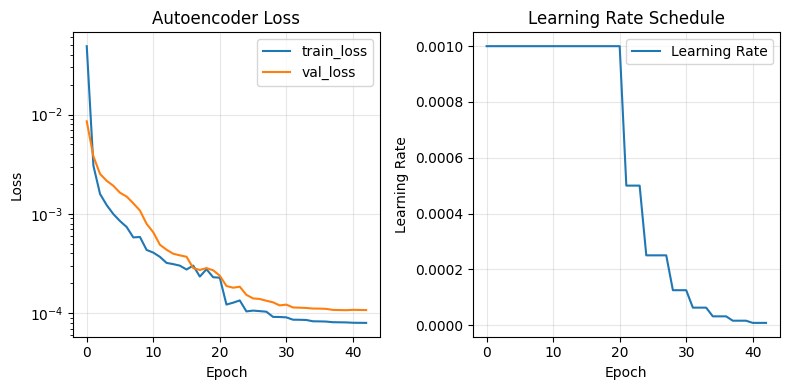

Extracting latent features...
Latent features shape: (123255, 16)

5. K-means clustering for 2017...
Clusters found: 15

6. Converting clusters -> binary forest/non-forest for 2017...

Cluster Statistics:
   cluster_id  mean_ndvi  mean_mndwi  pixel_count
0           0   0.326293   -0.361095         5195
1           1   0.603161   -0.287095        20180
2           2   0.176867   -0.144911          338
3           3   0.344837   -0.217521         2213
4           4   0.591442   -0.231552        16615

Classified 8 clusters as Forest, 7 as Non-forest
Binary map created and filtered

-- Trimming district edge pixels for better visualization --
Original district pixels: 123,255
After erosion (interior): 119,245

7. Calculating forest area statistics for 2017...
Pixel dimensions: 195.0 x 198.8 m
Pixel area: 0.038767 km²

🌳 2017 FOREST COVER STATISTICS:
  Forest pixels: 115,800
  Non-forest pixels: 7,318
  Total valid pixels: 123,118
  Forest area: 4489.21 km²
  Non-forest area: 283.70 km²
 

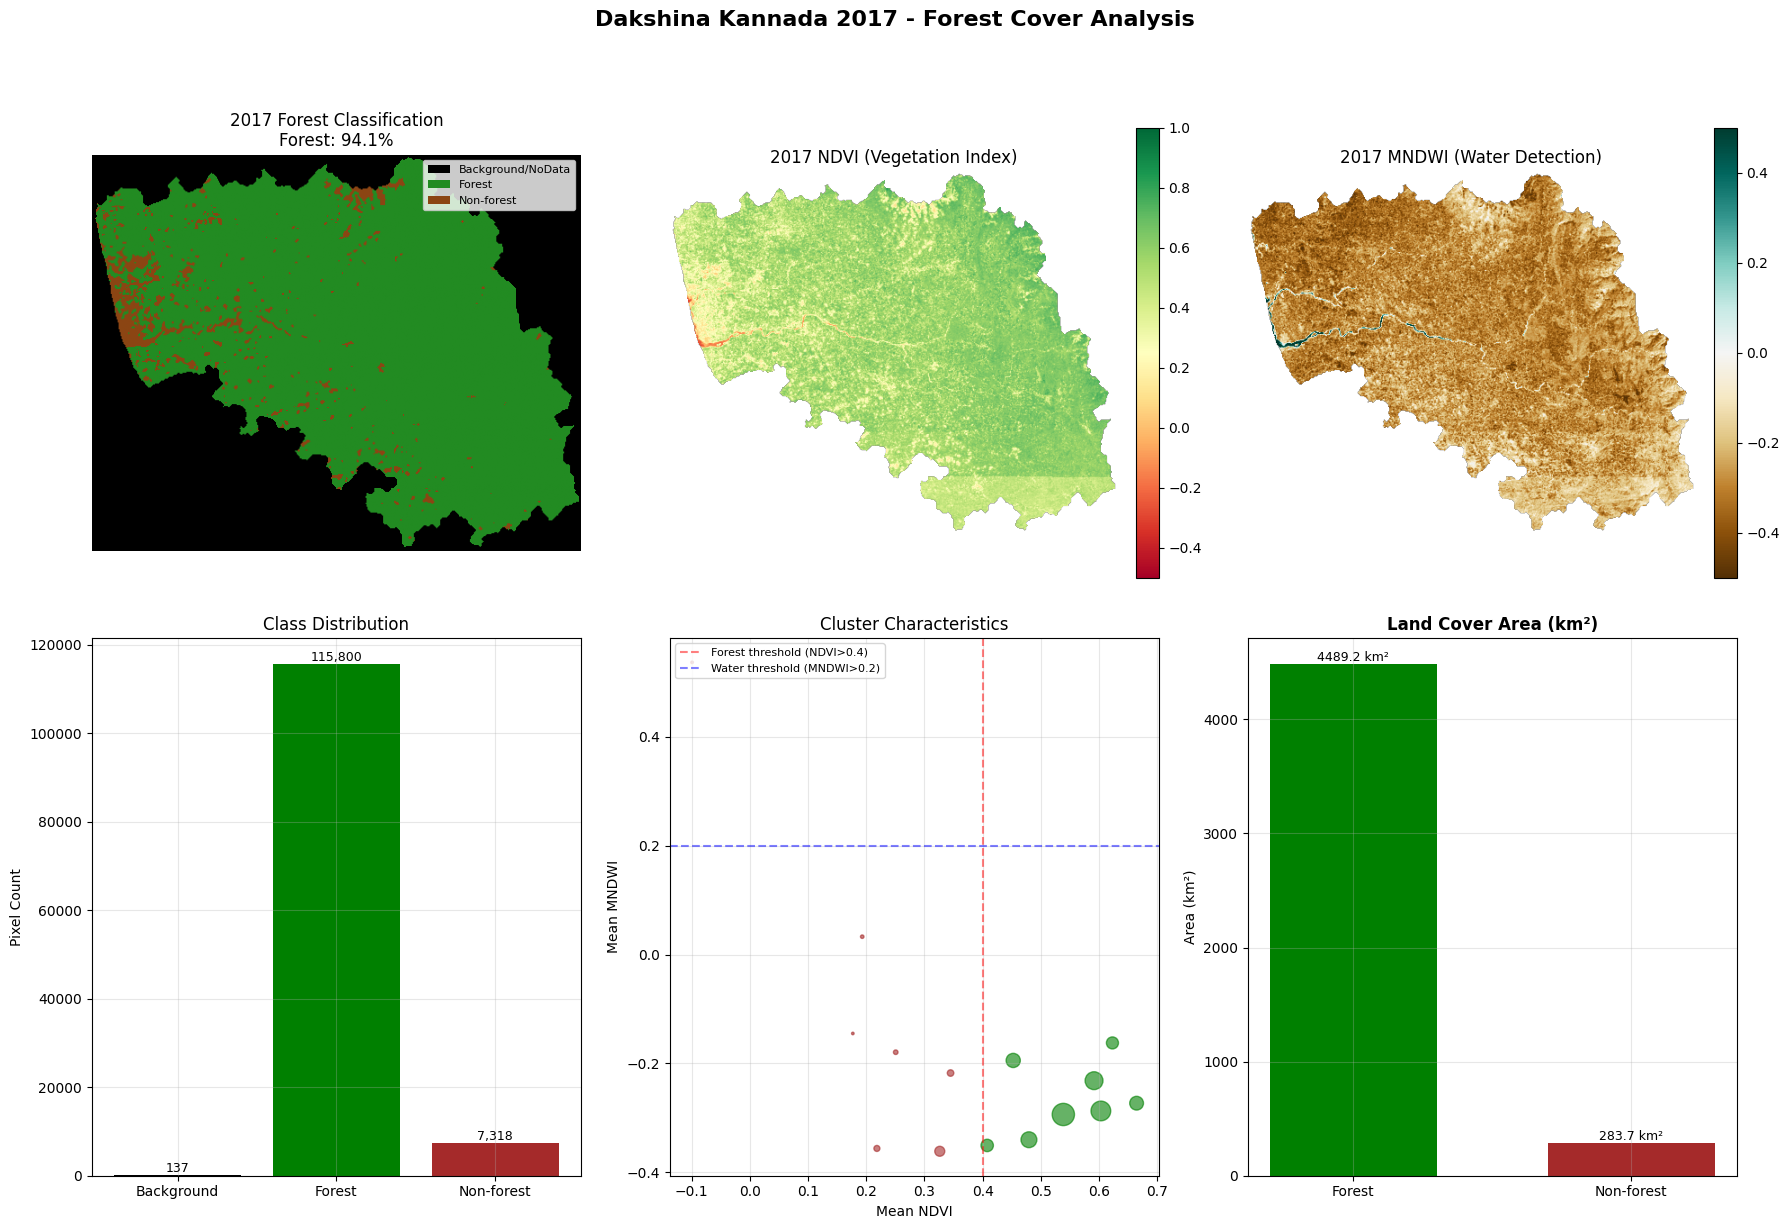


9. Saving 2017 results...
✓ Classification map saved: /content/drive/MyDrive/Dakshina_Kannada_2017/DK_LULC_2017_Autoencoder_Kmeans.tif
✓ Metrics saved: /content/drive/MyDrive/Dakshina_Kannada_2017/DK_2017_Forest_Metrics.csv
✓ Cluster analysis saved: /content/drive/MyDrive/Dakshina_Kannada_2017/DK_2017_Cluster_Analysis.csv
✓ Report saved: /content/drive/MyDrive/Dakshina_Kannada_2017/DK_2017_Analysis_Report.txt

✅ 2017 ANALYSIS COMPLETED SUCCESSFULLY!
Forest cover: 94.1% (4489.21 km²)
Output directory: /content/drive/MyDrive/Dakshina_Kannada_2017
Files created:
  • DK_LULC_2017_Autoencoder_Kmeans.tif (classification map)
  • DK_2017_Forest_Metrics.csv (statistics)
  • DK_2017_Cluster_Analysis.csv (cluster details)
  • DK_2017_Forest_Analysis.png (visualization)
  • DK_2017_Analysis_Report.txt (summary report)

✓ 2017 results saved for comparison: /content/drive/MyDrive/Dakshina_Kannada_2017/results_2017.pkl


In [ ]:
# ====================================================
# 2017 FOREST QUANTIFICATION - AUTOENCODER + K-MEANS
# (Same methodology as 2025, no validation with Dynamic World)
# ====================================================

# ----------------- Install & imports -----------------
!pip install -q rasterio scikit-learn tensorflow matplotlib pandas seaborn

import os, random
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling as WarpResampling
from rasterio.enums import Resampling
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from affine import Affine
from scipy.ndimage import median_filter, binary_erosion
from datetime import datetime

# Check if GPU is available
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ====================================================
# PATHS AND PARAMETERS FOR 2017
# ====================================================

# PATHS
INPUT_FILE_2017 = "/content/drive/MyDrive/GEE_exports/DK_2017_Final_Mosaic.tif"  # Your 2017 data
OUTPUT_DIR_2017 = "/content/drive/MyDrive/Dakshina_Kannada_2017"  # Output directory for 2017
os.makedirs(OUTPUT_DIR_2017, exist_ok=True)

# PARAMETERS (same as 2025 for consistency)
PARAMS = {
    'scale_factor': 0.05,        # 0.05 = 20x downsampling for memory
    'n_clusters': 15,
    'ae_epochs': 50,
    'batch_size': 128,
    'latent_dim': 16,
    'sample_frac': None,         # None = use all sampled pixels
    'earlystop_patience': 5,
    'reduce_lr_patience': 3,
    'min_lr': 1e-6,
    'min_delta': 1e-6,
    'seed': 42
}

# Reproducibility
np.random.seed(PARAMS['seed'])
random.seed(PARAMS['seed'])
tf.random.set_seed(PARAMS['seed'])

# ====================================================
# MAIN PROCESSING FUNCTION FOR 2017
# ====================================================

def process_2017_data():
    """Process 2017 data with the exact same pipeline as 2025"""

    print("\n" + "="*70)
    print("PROCESSING 2017 SATELLITE DATA")
    print("Data: Sentinel-2 TOA (Top of Atmosphere)")
    print("Period: January-February 2017")
    print("="*70)

    # ============== 1. LOAD DATA ==============
    print("\n1. Loading 2017 satellite data...")
    scale = PARAMS['scale_factor']

    with rasterio.open(INPUT_FILE_2017) as src:
        profile = src.profile.copy()
        original_transform = src.transform
        original_bounds = src.bounds
        original_crs = src.crs
        data = src.read(
            out_shape=(src.count, int(src.height * scale), int(src.width * scale)),
            resampling=Resampling.bilinear
        ).astype(np.float32)

    district_mask = np.any(data > 0, axis=0)
    max_val = np.nanmax(data)
    if max_val <= 0:
        raise ValueError("2017 input image has no positive values")
    data = data / max_val
    h, w = data.shape[1], data.shape[2]

    # Extract bands - note: S2 TOA bands might be in same order as S2 SR
    # Assuming same order: B2, B3, B4, B5, B6, B7, B8, B8A, B11, B12
    # Adjust indices if your 2017 data has different band order
    if data.shape[0] >= 10:  # Check if we have all bands
        blue, green, red, nir, swir1 = data[0], data[1], data[2], data[6], data[8]
    else:
        # If fewer bands, adjust indices
        print(f"Warning: Only {data.shape[0]} bands available")
        # Use first 5 bands as fallback
        blue, green, red, nir, swir1 = data[0], data[1], data[2], data[3], data[4]

    ndvi = np.clip((nir - red) / (nir + red + 1e-10), -1, 1)
    mndwi = np.clip((green - swir1) / (green + swir1 + 1e-10), -1, 1)
    ndbi = np.clip((swir1 - nir) / (swir1 + nir + 1e-10), -1, 1)

    print(f"Data shape: {data.shape}")
    print(f"Bands loaded: {src.count}")
    print(f"District mask pixels: {np.sum(district_mask):,} (downscale {scale})")
    print(f"Data range: {np.min(data):.4f} to {np.max(data):.4f}")

    # ============== 2. FEATURE EXTRACTION ==============
    print("\n2. Extracting features from 2017 data...")
    features = []
    coords = []
    y_coords, x_coords = np.where(district_mask)

    for y, x in zip(y_coords, x_coords):
        # Use available bands (up to 6 or whatever is available)
        n_bands_to_use = min(6, data.shape[0])
        spectral_features = [data[b, y, x] for b in range(n_bands_to_use)]

        # Add indices
        feature_vec = spectral_features + [
            ndvi[y, x], mndwi[y, x], ndbi[y, x],
            np.std([data[b, y, x] for b in range(min(3, data.shape[0]))])
        ]
        features.append(feature_vec)
        coords.append((y, x))

    features = np.array(features, dtype=np.float32)
    features[np.isnan(features)] = 0
    features[np.isinf(features)] = 0

    print(f"Feature matrix shape: {features.shape}")
    print(f"Features per pixel: {features.shape[1]}")

    # Optional quick-sample for tuning
    if PARAMS['sample_frac'] is not None and 0 < PARAMS['sample_frac'] < 1:
        n_samples = int(len(features) * PARAMS['sample_frac'])
        idx = np.random.choice(len(features), n_samples, replace=False)
        features = features[idx]
        coords = [coords[i] for i in idx]
        print(f"Sampled {n_samples} pixels; new features shape: {features.shape}")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features)
    print("Features standardized")

    # ============== 3. AUTOENCODER MODEL ==============
    print("\n3. Building Autoencoder for 2017...")
    input_dim = X_scaled.shape[1]
    latent_dim = PARAMS['latent_dim']
    l2 = 1e-6

    encoder = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2)),
        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(l2)),
        layers.Dense(latent_dim, activation='relu', name='latent')
    ], name='encoder')

    decoder = models.Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(input_dim, activation='linear')
    ], name='decoder')

    autoencoder = models.Sequential([encoder, decoder], name='autoencoder')
    autoencoder.compile(optimizer='adam', loss='mse')

    print(f"Autoencoder architecture:")
    print(f"  Input: {input_dim} features")
    print(f"  Latent space: {latent_dim} dimensions")
    autoencoder.summary()

    checkpoint_path = os.path.join(OUTPUT_DIR_2017, "best_autoencoder_2017.keras")
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=PARAMS['earlystop_patience'],
                      restore_best_weights=True, verbose=1, min_delta=PARAMS['min_delta']),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=PARAMS['reduce_lr_patience'],
                          min_lr=PARAMS['min_lr'], verbose=1),
        ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
    ]

    print(f"\n4. Training Autoencoder for 2017 (max epochs={PARAMS['ae_epochs']})...")
    history = autoencoder.fit(
        X_scaled, X_scaled,
        epochs=PARAMS['ae_epochs'],
        batch_size=PARAMS['batch_size'],
        validation_split=0.10,
        shuffle=True,
        callbacks=callbacks,
        verbose=1
    )

    # Plot training history
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='train_loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='val_loss')
    plt.yscale('log')
    plt.title('Autoencoder Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot learning rate if available
    plt.subplot(1, 2, 2)
    if 'learning_rate' in history.history:
        plt.plot(history.history['learning_rate'], label='Learning Rate')
        plt.title('Learning Rate Schedule')
        plt.xlabel('Epoch')
        plt.ylabel('Learning Rate')
        plt.legend()
    else:
        # Create a simple learning rate decay visualization
        initial_lr = 0.001  # Default Adam learning rate
        epochs = range(1, len(history.history['loss']) + 1)
        # Simulate typical learning rate decay
        lr_values = [initial_lr * (0.5 ** (i // 10)) for i in range(len(epochs))]
        plt.plot(epochs, lr_values, label='Learning Rate (estimated)')
        plt.title('Learning Rate Schedule (estimated)')
        plt.xlabel('Epoch')
        plt.ylabel('Learning Rate')
        plt.legend()

    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR_2017, "autoencoder_training_2017.png"), dpi=150)
    plt.show()

    print("Extracting latent features...")
    Z = encoder.predict(X_scaled, verbose=0)
    print(f"Latent features shape: {Z.shape}")

    # ============== 4. K-MEANS CLUSTERING ==============
    print("\n5. K-means clustering for 2017...")
    kmeans = KMeans(n_clusters=PARAMS['n_clusters'], random_state=PARAMS['seed'], n_init=15)
    labels = kmeans.fit_predict(Z)
    print(f"Clusters found: {len(np.unique(labels))}")

    # ============== 5. BINARY CLASSIFICATION ==============
    print("\n6. Converting clusters -> binary forest/non-forest for 2017...")
    cluster_stats = []
    for cluster_id in range(PARAMS['n_clusters']):
        idxs = np.where(labels == cluster_id)[0]
        if len(idxs) > 0:
            cluster_ndvi = np.mean([ndvi[coords[i][0], coords[i][1]] for i in idxs])
            cluster_mndwi = np.mean([mndwi[coords[i][0], coords[i][1]] for i in idxs])
            cluster_stats.append({
                'cluster_id': cluster_id,
                'mean_ndvi': cluster_ndvi,
                'mean_mndwi': cluster_mndwi,
                'pixel_count': len(idxs),
                'std_ndvi': np.std([ndvi[coords[i][0], coords[i][1]] for i in idxs]),
                'std_mndwi': np.std([mndwi[coords[i][0], coords[i][1]] for i in idxs])
            })

    cluster_df = pd.DataFrame(cluster_stats).sort_values('cluster_id')

    # Print cluster statistics
    print("\nCluster Statistics:")
    print(cluster_df[['cluster_id', 'mean_ndvi', 'mean_mndwi', 'pixel_count']].head())

    # Classification rules (same as 2025)
    def classify_cluster_ae(row):
        if row['mean_ndvi'] > 0.40:
            return 1  # Forest
        elif row['mean_mndwi'] > 0.2:
            return 2  # Water (Non-forest)
        else:
            return 2  # Non-forest

    cluster_df['binary_class'] = cluster_df.apply(classify_cluster_ae, axis=1)

    # Count classes
    forest_clusters = np.sum(cluster_df['binary_class'] == 1)
    nonforest_clusters = np.sum(cluster_df['binary_class'] == 2)
    print(f"\nClassified {forest_clusters} clusters as Forest, {nonforest_clusters} as Non-forest")

    # Create binary map
    binary_map = np.zeros((h, w), dtype=np.uint8)
    for i, (y, x) in enumerate(coords):
        cluster_id = labels[i]
        binary_map[y, x] = int(cluster_df.loc[cluster_df['cluster_id'] == cluster_id, 'binary_class'].iloc[0])

    # Apply median filter to reduce noise
    binary_map = median_filter(binary_map, size=3)
    print("Binary map created and filtered")

    # Erode district mask for better visualization (trim edges)
    print("\n-- Trimming district edge pixels for better visualization --")
    trim_pixels = 2
    district_eroded = binary_erosion(district_mask, iterations=trim_pixels)
    print(f"Original district pixels: {np.sum(district_mask):,}")
    print(f"After erosion (interior): {np.sum(district_eroded):,}")

    # ============== 6. AREA CALCULATION ==============
    print("\n7. Calculating forest area statistics for 2017...")

    # Calculate pixel size in meters
    new_transform = Affine(
        original_transform.a / scale, original_transform.b, original_transform.c,
        original_transform.d, original_transform.e / scale, original_transform.f
    )

    pixel_width_deg = abs(new_transform.a)
    pixel_height_deg = abs(new_transform.e)
    center_lat = (original_bounds.top + original_bounds.bottom) / 2.0
    lat_rad = np.deg2rad(center_lat)

    # Convert degrees to meters at this latitude
    meters_per_deg_lat = 111132.92 - 559.82 * np.cos(2 * lat_rad) + 1.175 * np.cos(4 * lat_rad)
    meters_per_deg_lon = 111412.84 * np.cos(lat_rad) - 93.5 * np.cos(3 * lat_rad) + 0.118 * np.cos(5 * lat_rad)

    pixel_width_m = pixel_width_deg * meters_per_deg_lon
    pixel_height_m = pixel_height_deg * meters_per_deg_lat
    pixel_area_km2 = (pixel_width_m * pixel_height_m) / 1e6

    print(f"Pixel dimensions: {pixel_width_m:.1f} x {pixel_height_m:.1f} m")
    print(f"Pixel area: {pixel_area_km2:.6f} km²")

    # Count pixels
    forest_pixels = np.sum((binary_map == 1) & district_mask)
    non_forest_pixels = np.sum((binary_map == 2) & district_mask)
    total_district_pixels = forest_pixels + non_forest_pixels

    # Calculate areas
    forest_area_km2 = forest_pixels * pixel_area_km2
    non_forest_area_km2 = non_forest_pixels * pixel_area_km2
    total_district_area_km2 = forest_area_km2 + non_forest_area_km2
    forest_percentage = (forest_pixels / total_district_pixels) * 100 if total_district_pixels > 0 else 0

    print(f"\n🌳 2017 FOREST COVER STATISTICS:")
    print(f"  Forest pixels: {forest_pixels:,}")
    print(f"  Non-forest pixels: {non_forest_pixels:,}")
    print(f"  Total valid pixels: {total_district_pixels:,}")
    print(f"  Forest area: {forest_area_km2:.2f} km²")
    print(f"  Non-forest area: {non_forest_area_km2:.2f} km²")
    print(f"  Total district area: {total_district_area_km2:.2f} km²")
    print(f"  Forest percentage: {forest_percentage:.1f}%")

    # ============== 7. VISUALIZATION ==============
    print("\n8. Creating visualizations for 2017...")

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Dakshina Kannada 2017 - Forest Cover Analysis',
                 fontsize=16, fontweight='bold', y=1.02)

    cmap_binary = ListedColormap(['#000000', '#228B22', '#8B4513'])  # Black, Forest Green, Brown

    # 1. Classification Map (with eroded mask for clean edges)
    masked_class = binary_map.copy()
    masked_class[~district_eroded] = 0  # Set edges to background
    axes[0,0].imshow(masked_class, cmap=cmap_binary, vmin=0, vmax=2)
    axes[0,0].set_title(f'2017 Forest Classification\nForest: {forest_percentage:.1f}%')
    axes[0,0].axis('off')

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#000000', label='Background/NoData'),
        Patch(facecolor='#228B22', label='Forest'),
        Patch(facecolor='#8B4513', label='Non-forest')
    ]
    axes[0,0].legend(handles=legend_elements, loc='upper right', fontsize=8)

    # 2. NDVI Map
    ndvi_masked = ndvi.copy()
    ndvi_masked[~district_eroded] = np.nan
    im1 = axes[0,1].imshow(ndvi_masked, cmap='RdYlGn', vmin=-0.5, vmax=1)
    axes[0,1].set_title('2017 NDVI (Vegetation Index)')
    axes[0,1].axis('off')
    plt.colorbar(im1, ax=axes[0,1], fraction=0.046, pad=0.04)

    # 3. MNDWI Map (Water Detection)
    mndwi_masked = mndwi.copy()
    mndwi_masked[~district_eroded] = np.nan
    im2 = axes[0,2].imshow(mndwi_masked, cmap='BrBG', vmin=-0.5, vmax=0.5)
    axes[0,2].set_title('2017 MNDWI (Water Detection)')
    axes[0,2].axis('off')
    plt.colorbar(im2, ax=axes[0,2], fraction=0.046, pad=0.04)

    # 4. Class Distribution
    unique, counts = np.unique(binary_map[district_mask], return_counts=True)
    class_names = ['Background', 'Forest', 'Non-forest']
    colors = ['black', 'green', 'brown']

    # Filter for classes present
    present_classes = []
    present_counts = []
    present_colors = []

    for i, class_val in enumerate(unique):
        if class_val < len(class_names):
            present_classes.append(class_names[class_val])
            present_counts.append(counts[i])
            if class_val < len(colors):
                present_colors.append(colors[class_val])

    if present_classes:  # Check if we have any classes to plot
        axes[1,0].bar(present_classes, present_counts, color=present_colors)
        axes[1,0].set_title('Class Distribution')
        axes[1,0].set_ylabel('Pixel Count')
        axes[1,0].grid(True, alpha=0.3)

        # Add value labels on bars
        for i, (cls, count) in enumerate(zip(present_classes, present_counts)):
            axes[1,0].text(i, count, f'{count:,}', ha='center', va='bottom', fontsize=9)
    else:
        axes[1,0].text(0.5, 0.5, 'No classes found',
                      ha='center', va='center', transform=axes[1,0].transAxes)
        axes[1,0].set_title('Class Distribution')
        axes[1,0].axis('off')

    # 5. Cluster Characteristics
    if not cluster_df.empty:
        axes[1,1].scatter(cluster_df['mean_ndvi'], cluster_df['mean_mndwi'],
                         s=cluster_df['pixel_count']/100, alpha=0.6,
                         c=cluster_df['binary_class'].map({1: 'green', 2: 'brown'}))
        axes[1,1].axvline(x=0.4, color='red', linestyle='--', alpha=0.5, label='Forest threshold (NDVI>0.4)')
        axes[1,1].axhline(y=0.2, color='blue', linestyle='--', alpha=0.5, label='Water threshold (MNDWI>0.2)')
        axes[1,1].set_xlabel('Mean NDVI')
        axes[1,1].set_ylabel('Mean MNDWI')
        axes[1,1].set_title('Cluster Characteristics')
        axes[1,1].legend(loc='upper left', fontsize=8)
        axes[1,1].grid(True, alpha=0.3)
    else:
        axes[1,1].text(0.5, 0.5, 'No cluster data available',
                      ha='center', va='center', transform=axes[1,1].transAxes)
        axes[1,1].set_title('Cluster Characteristics')
        axes[1,1].axis('off')

    # 6. Area Chart
    categories = ['Forest', 'Non-forest']
    areas = [forest_area_km2, non_forest_area_km2]
    colors_area = ['green', 'brown']

    axes[1,2].bar(categories, areas, color=colors_area, width=0.6)
    axes[1,2].set_title('Land Cover Area (km²)', fontweight='bold')
    axes[1,2].set_ylabel('Area (km²)')
    axes[1,2].grid(True, alpha=0.3)

    # Add value labels on bars
    for i, (category, area) in enumerate(zip(categories, areas)):
        axes[1,2].text(i, area, f'{area:.1f} km²', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR_2017, "DK_2017_Forest_Analysis.png"), dpi=300, bbox_inches='tight')
    plt.show()

    # ============== 8. SAVE RESULTS ==============
    print("\n9. Saving 2017 results...")

    # Save classification map
    masked_save = binary_map.copy().astype(np.uint8)
    masked_save[~district_eroded] = 255  # Use 255 as NoData

    # Update metadata
    meta = profile.copy()
    meta.update({
        "driver": "GTiff",
        "height": h,
        "width": w,
        "count": 1,
        "dtype": "uint8",
        "nodata": 255,
        "transform": new_transform,
        "compress": "LZW",
        "crs": original_crs
    })

    output_file = os.path.join(OUTPUT_DIR_2017, "DK_LULC_2017_Autoencoder_Kmeans.tif")
    with rasterio.open(output_file, "w", **meta) as dst:
        dst.write(masked_save, 1)
        try:
            dst.write_colormap(1, {1: (34, 139, 34),   # Forest green
                                  2: (139, 69, 19),   # Brown
                                  255: (0, 0, 0)})    # Black for NoData
        except:
            print("Note: Could not write colormap (not critical)")

    print(f"✓ Classification map saved: {output_file}")

    # Save metrics
    results_data = {
        'Year': [2017],
        'Dataset': ['Sentinel-2 TOA'],
        'Period': ['Jan-Feb 2017'],
        'Processing_Level': ['Autoencoder + K-means'],
        'Forest_Pixels': [forest_pixels],
        'NonForest_Pixels': [non_forest_pixels],
        'Total_Pixels': [total_district_pixels],
        'Forest_Percentage': [forest_percentage],
        'Forest_Area_km2': [forest_area_km2],
        'NonForest_Area_km2': [non_forest_area_km2],
        'Total_Area_km2': [total_district_area_km2],
        'Pixel_Area_km2': [pixel_area_km2],
        'Scale_Factor': [scale],
        'N_Clusters': [PARAMS['n_clusters']],
        'Processing_Date': [datetime.now().strftime('%Y-%m-%d %H:%M:%S')]
    }

    results_df = pd.DataFrame(results_data)
    metrics_file = os.path.join(OUTPUT_DIR_2017, "DK_2017_Forest_Metrics.csv")
    results_df.to_csv(metrics_file, index=False)
    print(f"✓ Metrics saved: {metrics_file}")

    # Save cluster analysis
    cluster_file = os.path.join(OUTPUT_DIR_2017, "DK_2017_Cluster_Analysis.csv")
    cluster_df.to_csv(cluster_file, index=False)
    print(f"✓ Cluster analysis saved: {cluster_file}")

    # Save summary report
    report_file = os.path.join(OUTPUT_DIR_2017, "DK_2017_Analysis_Report.txt")
    with open(report_file, 'w') as f:
        f.write("="*80 + "\n")
        f.write("DAKSHINA KANNADA 2017 FOREST COVER ANALYSIS REPORT\n")
        f.write("="*80 + "\n\n")

        f.write("SUMMARY\n")
        f.write("-"*40 + "\n")
        f.write(f"Forest cover in 2017: {forest_percentage:.1f}%\n")
        f.write(f"Forest area: {forest_area_km2:.2f} km²\n")
        f.write(f"Non-forest area: {non_forest_area_km2:.2f} km²\n")
        f.write(f"Total district area: {total_district_area_km2:.2f} km²\n\n")

        f.write("METHODOLOGY\n")
        f.write("-"*40 + "\n")
        f.write("1. Data: Sentinel-2 TOA (Top of Atmosphere)\n")
        f.write("2. Period: January-February 2017\n")
        f.write("3. Processing: Autoencoder + K-means clustering\n")
        f.write("4. Classification rules:\n")
        f.write("   - Forest: NDVI > 0.4\n")
        f.write("   - Water: MNDWI > 0.2 (classified as non-forest)\n")
        f.write("   - Non-forest: All other pixels\n")
        f.write(f"5. Parameters: {PARAMS['n_clusters']} clusters, scale factor {scale}\n")
        f.write("6. Validation: None (Dynamic World not available for 2017)\n\n")

        f.write("DATA QUALITY NOTES\n")
        f.write("-"*40 + "\n")
        f.write("1. 2017 data is TOA (Top of Atmosphere) reflectance\n")
        f.write("2. 2025 comparison data is SR (Surface Reflectance)\n")
        f.write("3. Direct comparison should consider this difference\n")
        f.write("4. Classification thresholds optimized for vegetation detection\n")

    print(f"✓ Report saved: {report_file}")

    # ============== RETURN RESULTS ==============
    results_2017 = {
        'year': 2017,
        'binary_map': binary_map,
        'forest_percentage': forest_percentage,
        'forest_area_km2': forest_area_km2,
        'forest_pixels': forest_pixels,
        'total_pixels': total_district_pixels,
        'pixel_area_km2': pixel_area_km2,
        'display_mask': district_eroded,
        'district_mask': district_mask,
        'ndvi': ndvi,
        'results_df': results_df,
        'cluster_df': cluster_df,
        'original_shape': (h, w),
        'transform': new_transform,
        'meta': meta
    }

    print("\n" + "="*70)
    print("✅ 2017 ANALYSIS COMPLETED SUCCESSFULLY!")
    print("="*70)
    print(f"Forest cover: {forest_percentage:.1f}% ({forest_area_km2:.2f} km²)")
    print(f"Output directory: {OUTPUT_DIR_2017}")
    print(f"Files created:")
    print(f"  • DK_LULC_2017_Autoencoder_Kmeans.tif (classification map)")
    print(f"  • DK_2017_Forest_Metrics.csv (statistics)")
    print(f"  • DK_2017_Cluster_Analysis.csv (cluster details)")
    print(f"  • DK_2017_Forest_Analysis.png (visualization)")
    print(f"  • DK_2017_Analysis_Report.txt (summary report)")

    return results_2017

# ====================================================
# RUN THE 2017 ANALYSIS
# ====================================================

# Run the function
results_2017 = process_2017_data()

# Save results for comparison later
import pickle
results_2017_file = os.path.join(OUTPUT_DIR_2017, "results_2017.pkl")
with open(results_2017_file, 'wb') as f:
    pickle.dump(results_2017, f)
print(f"\n✓ 2017 results saved for comparison: {results_2017_file}")

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

2017 DEEP EMBEDDED CLUSTERING (DEC) ANALYSIS
Data: Sentinel-2 TOA (Top of Atmosphere)
Period: January-February 2017

1. Loading 2017 satellite data...
Data shape: (10, 403, 497)
District area: 123,255 pixels (downscale 0.05)
Data range: nan to nan

2. Extracting features from 2017 data...
Feature matrix shape: (123255, 10)
Features per pixel: 10
Training samples: 110929, Validation samples: 12326

3. Building and pre-training Autoencoder for 2017 DEC...
Pre-training encoder (max epochs=50)...
Epoch 1/50
867/867 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1670 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 2/50
867/867 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0042 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 3/50
867/867 ━━━━━━━━━━━━━━━━━━━━ 2s 

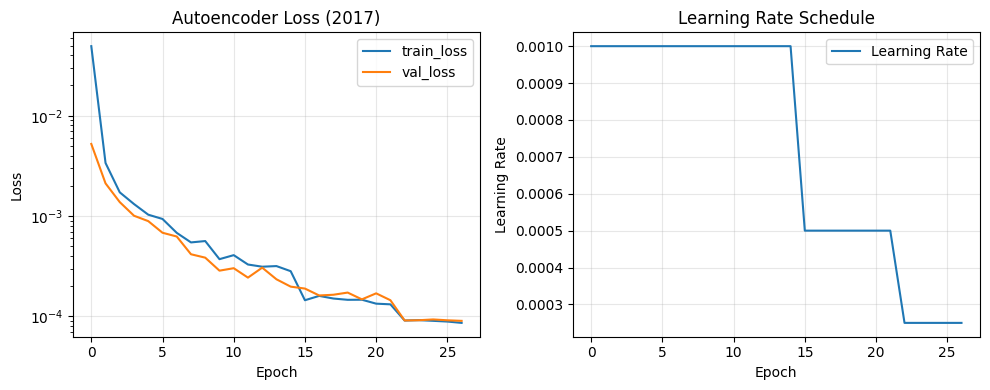

Initial latent features shape: (123255, 16)

4. Initializing clusters with K-means...
Initial clusters: 15
Cluster centers shape: (15, 16)

5. DEC training (student-t soft assignments) - training encoder + centers...
Starting DEC training with learning rate: 1e-05
DEC Epoch 0: Loss=0.183959, Active clusters=15, Patience=0/10
DEC Epoch 5: Loss=0.183799, Active clusters=15, Patience=1/10
DEC Epoch 10: Loss=0.183640, Active clusters=15, Patience=2/10
DEC Epoch 15: Loss=0.183483, Active clusters=15, Patience=3/10
DEC Epoch 20: Loss=0.183326, Active clusters=15, Patience=0/10
DEC Epoch 25: Loss=0.183171, Active clusters=15, Patience=1/10
DEC Epoch 30: Loss=0.183016, Active clusters=15, Patience=2/10
DEC Epoch 35: Loss=0.182862, Active clusters=15, Patience=3/10
DEC Epoch 40: Loss=0.182710, Active clusters=15, Patience=0/10
DEC Epoch 45: Loss=0.182557, Active clusters=15, Patience=1/10
DEC training completed.
AE Epochs: 27, DEC Epochs: 50
Final clusters: 15


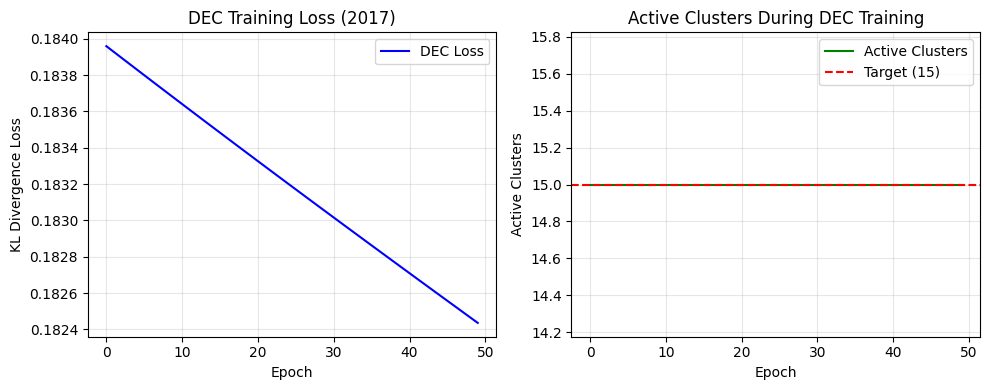


6. Converting clusters to binary forest/non-forest...

Cluster Statistics (top 5):
   cluster_id  mean_ndvi  mean_mndwi  pixel_count
0           0   0.542818   -0.294009        26885
1           1   0.233505   -0.368494         2595
2           2   0.611469   -0.152908         7015
3           3   0.177269   -0.142215          328
4           4   0.340773   -0.218301         2210

Classified 8 clusters as Forest, 7 as Non-forest
Binary classification map ready.

-- Trimming district edge pixels for better visualization --
Original district pixels: 123,255
After erosion (interior): 119,245

7. Calculating forest area statistics for 2017...
Pixel dimensions: 195.0 x 198.8 m
Pixel area: 0.038767 km²

🌳 2017 DEEP EMBEDDED CLUSTERING RESULTS:
  Forest pixels: 114,965
  Non-forest pixels: 8,153
  Total valid pixels: 123,118
  Forest area: 4456.84 km²
  Non-forest area: 316.07 km²
  Total district area: 4772.91 km²
  Forest percentage: 93.4%

8. Creating visualizations for 2017 DEC...


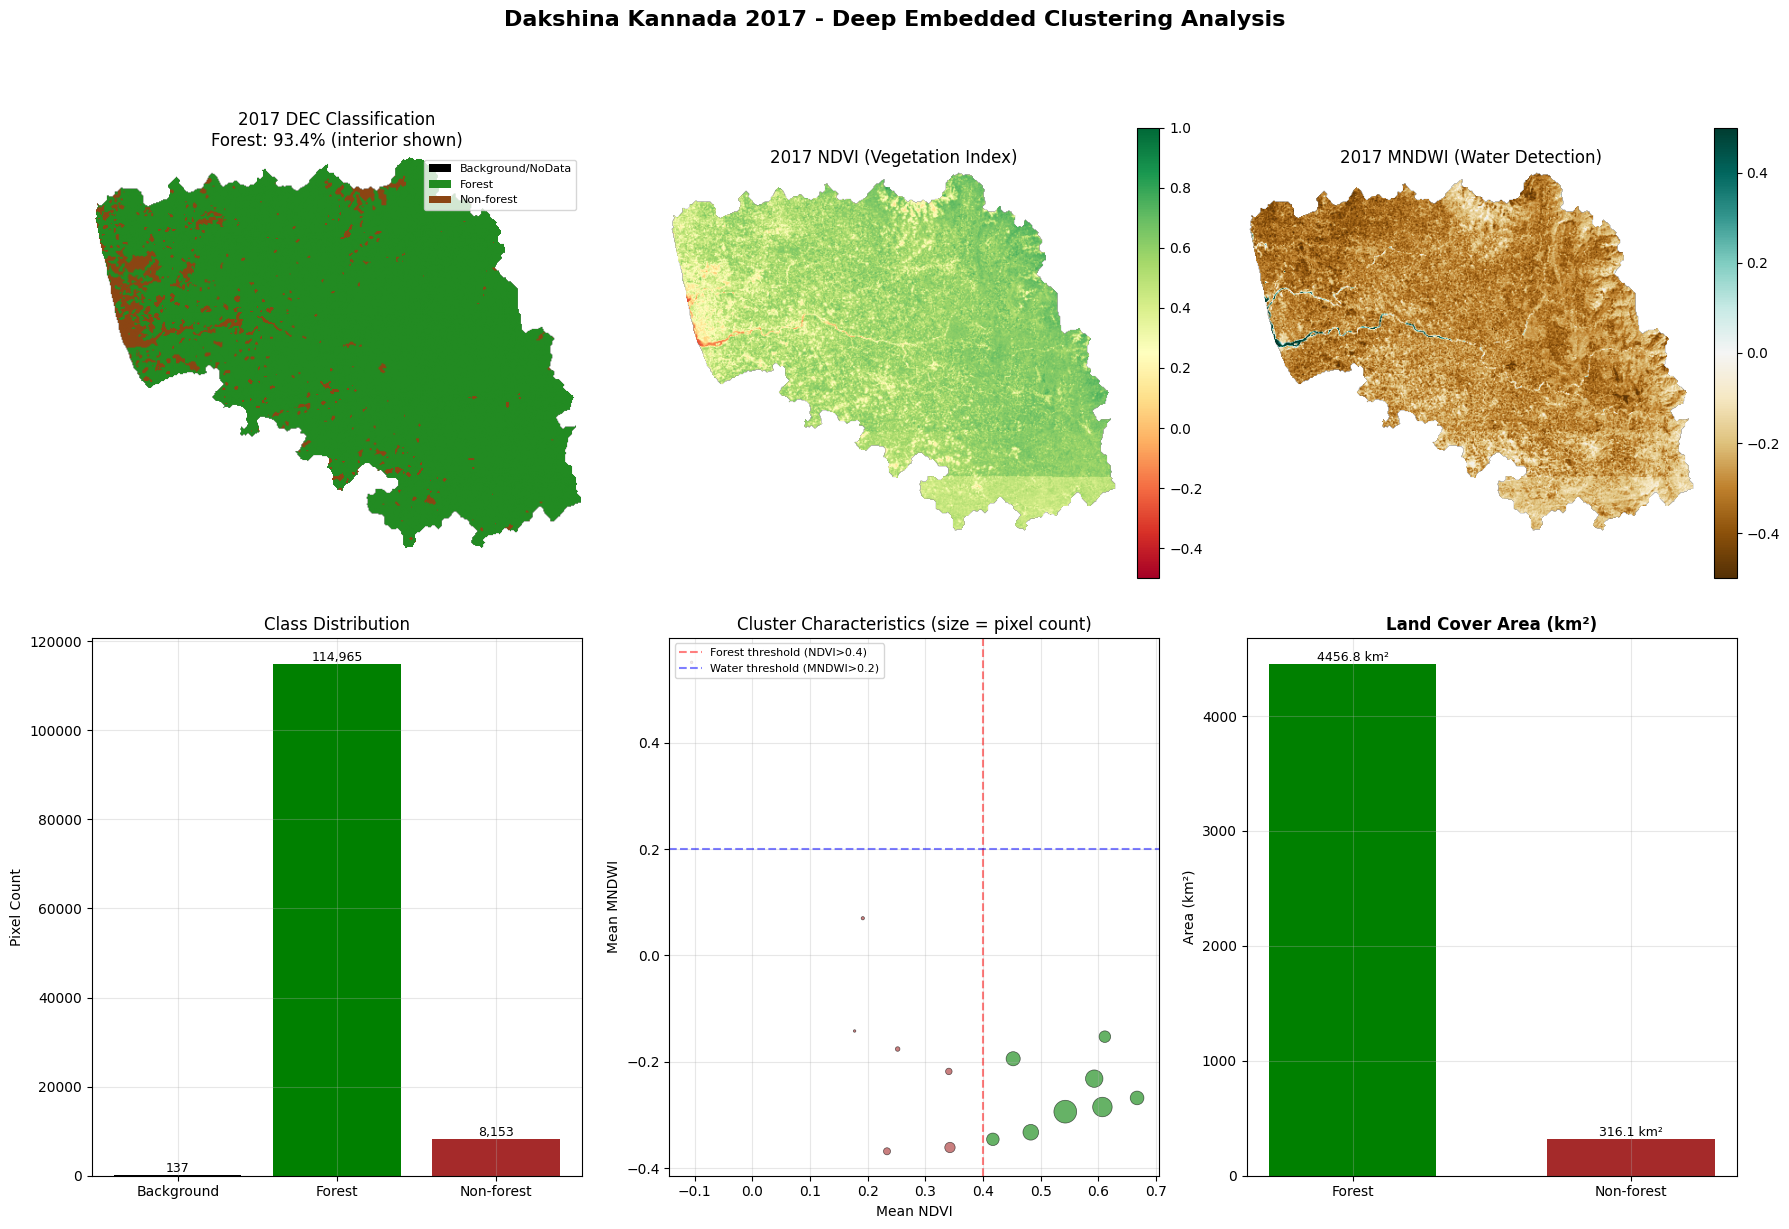


9. Saving 2017 DEC results...
✓ Classification map saved: /content/drive/MyDrive/Dakshina_Kannada_2017_DEC/DK_LULC_2017_Deep_Embedded_Clustering.tif
✓ Metrics saved: /content/drive/MyDrive/Dakshina_Kannada_2017_DEC/DK_2017_DEC_Metrics.csv
✓ Cluster analysis saved: /content/drive/MyDrive/Dakshina_Kannada_2017_DEC/DK_2017_DEC_Cluster_Analysis.csv
✓ Training histories saved
✓ Report saved: /content/drive/MyDrive/Dakshina_Kannada_2017_DEC/DK_2017_DEC_Analysis_Report.txt

✅ 2017 DEEP EMBEDDED CLUSTERING ANALYSIS COMPLETED!
Forest cover: 93.4% (4456.84 km²)
Output directory: /content/drive/MyDrive/Dakshina_Kannada_2017_DEC
Files created:
  • DK_LULC_2017_Deep_Embedded_Clustering.tif
  • DK_2017_DEC_Metrics.csv
  • DK_2017_DEC_Cluster_Analysis.csv
  • DK_2017_DEC_Analysis.png
  • results_2017_dec.pkl (for comparison)


In [ ]:
# ====================================================
# 2017 DEEP EMBEDDED CLUSTERING (DEC) ANALYSIS
# Same methodology as 2025 DEC model
# ====================================================

# ----------------- Install & imports -----------------
!pip install -q rasterio scikit-learn tensorflow matplotlib pandas seaborn

import os, random
import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from affine import Affine
from scipy.ndimage import median_filter, binary_erosion
from datetime import datetime

# Check GPU
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ====================================================
# PATHS AND PARAMETERS FOR 2017 DEC
# ====================================================

# PATHS
INPUT_FILE_2017 = "/content/drive/MyDrive/GEE_exports/DK_2017_Final_Mosaic.tif"  # Your 2017 data
OUTPUT_DIR_2017 = "/content/drive/MyDrive/Dakshina_Kannada_2017_DEC"  # Separate output for DEC
os.makedirs(OUTPUT_DIR_2017, exist_ok=True)

# DEC Parameters (same as 2025 for consistency)
PARAMS = {
    'scale_factor': 0.05,   # downscale for speed; use 1.0 for full resolution
    'n_clusters': 15,
    'max_epochs': 50,
    'patience': 10,
    'min_delta': 1e-4,
    'seed': 42,
    'learning_rate': 1e-5,  # For DEC training
    'batch_size': 128
}

# Files for saving models
AE_WEIGHTS_FILE = os.path.join(OUTPUT_DIR_2017, "best_autoencoder_dec_2017.keras")
DEC_FINETUNED_AE = os.path.join(OUTPUT_DIR_2017, "best_autoencoder_dec_finetuned_2017.keras")

# Reproducibility
np.random.seed(PARAMS['seed'])
random.seed(PARAMS['seed'])
tf.random.set_seed(PARAMS['seed'])

print("\n" + "="*70)
print("2017 DEEP EMBEDDED CLUSTERING (DEC) ANALYSIS")
print("Data: Sentinel-2 TOA (Top of Atmosphere)")
print("Period: January-February 2017")
print("="*70)

# ============== 1. LOAD 2017 DATA ==============
print("\n1. Loading 2017 satellite data...")
scale = PARAMS['scale_factor']

with rasterio.open(INPUT_FILE_2017) as src:
    profile = src.profile.copy()
    original_transform = src.transform
    original_bounds = src.bounds
    original_crs = src.crs
    data = src.read(
        out_shape=(src.count, int(src.height * scale), int(src.width * scale)),
        resampling=Resampling.bilinear
    ).astype(np.float32)

# Create district mask and normalize
district_mask = np.any(data > 0, axis=0)
max_val = np.nanmax(data)
if max_val <= 0:
    raise ValueError("2017 input image has no positive values")
data = data / max_val
h, w = data.shape[1], data.shape[2]

# Extract bands (adjust indices if needed)
if data.shape[0] >= 10:
    blue, green, red, nir, swir1 = data[0], data[1], data[2], data[6], data[8]
else:
    # Fallback if fewer bands
    print(f"Warning: Only {data.shape[0]} bands available, using first 5")
    blue, green, red, nir, swir1 = data[0], data[1], data[2], data[3], data[4]

# Calculate spectral indices
ndvi = np.clip((nir - red) / (nir + red + 1e-10), -1, 1)
mndwi = np.clip((green - swir1) / (green + swir1 + 1e-10), -1, 1)
ndbi = np.clip((swir1 - nir) / (swir1 + nir + 1e-10), -1, 1)

print(f"Data shape: {data.shape}")
print(f"District area: {np.sum(district_mask):,} pixels (downscale {scale})")
print(f"Data range: {np.min(data):.4f} to {np.max(data):.4f}")

# ============== 2. FEATURE EXTRACTION ==============
print("\n2. Extracting features from 2017 data...")
features = []
coords = []
y_coords, x_coords = np.where(district_mask)

for y, x in zip(y_coords, x_coords):
    # Use available bands
    n_bands_to_use = min(6, data.shape[0])
    spectral_features = [data[b, y, x] for b in range(n_bands_to_use)]

    # Add indices
    feature_vec = spectral_features + [
        ndvi[y, x], mndwi[y, x], ndbi[y, x],
        np.std([data[b, y, x] for b in range(min(3, data.shape[0]))])
    ]
    features.append(feature_vec)
    coords.append((y, x))

features = np.array(features, dtype=np.float32)
features[np.isnan(features)] = 0
features[np.isinf(features)] = 0

print(f"Feature matrix shape: {features.shape}")
print(f"Features per pixel: {features.shape[1]}")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Split for autoencoder validation
X_train, X_val, _, _ = train_test_split(
    X_scaled, X_scaled,
    test_size=0.1,
    random_state=PARAMS['seed']
)

print(f"Training samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}")

# ============== 3. PRETRAIN AUTOENCODER ==============
print("\n3. Building and pre-training Autoencoder for 2017 DEC...")

input_dim = X_scaled.shape[1]

# Encoder
encoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu', name='latent')  # latent dimension 16
], name='encoder')

# Decoder
decoder = models.Sequential([
    layers.Input(shape=(16,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(input_dim, activation='linear')
], name='decoder')

autoencoder = models.Sequential([encoder, decoder], name='autoencoder')
autoencoder.compile(optimizer='adam', loss='mse')

# Autoencoder callbacks
ae_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=PARAMS['patience'],
        min_delta=PARAMS['min_delta'],
        verbose=1,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=AE_WEIGHTS_FILE,
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

print(f"Pre-training encoder (max epochs={PARAMS['max_epochs']})...")
ae_history = autoencoder.fit(
    X_train, X_train,
    epochs=PARAMS['max_epochs'],
    batch_size=PARAMS['batch_size'],
    validation_data=(X_val, X_val),
    callbacks=ae_callbacks,
    verbose=1
)

# Load best AE weights
try:
    autoencoder.load_weights(AE_WEIGHTS_FILE)
    print("✓ Loaded best autoencoder weights from checkpoint")
except Exception as e:
    print("Warning: failed to load AE weights from checkpoint:", e)

print(f"Autoencoder pre-training completed. Epochs run: {len(ae_history.history['loss'])}")

# Plot AE training history
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(ae_history.history['loss'], label='train_loss')
plt.plot(ae_history.history['val_loss'], label='val_loss')
plt.yscale('log')
plt.title('Autoencoder Loss (2017)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
if 'learning_rate' in ae_history.history:
    plt.plot(ae_history.history['learning_rate'], label='Learning Rate')
else:
    # Simulate learning rate schedule
    epochs = range(1, len(ae_history.history['loss']) + 1)
    lr_values = [0.001 * (0.5 ** (i // 10)) for i in range(len(epochs))]
    plt.plot(epochs, lr_values, label='Learning Rate (estimated)')
plt.title('Learning Rate Schedule')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_2017, "dec_autoencoder_training_2017.png"), dpi=150)
plt.show()

# Get initial latent features
Z_init = encoder.predict(X_scaled, verbose=0)
print(f"Initial latent features shape: {Z_init.shape}")

# ============== 4. INITIAL K-MEANS CLUSTERING ==============
print("\n4. Initializing clusters with K-means...")
kmeans = KMeans(n_clusters=PARAMS['n_clusters'], random_state=PARAMS['seed'], n_init=15)
initial_labels = kmeans.fit_predict(Z_init)
cluster_centers = kmeans.cluster_centers_

print(f"Initial clusters: {len(np.unique(initial_labels))}")
print(f"Cluster centers shape: {cluster_centers.shape}")

# ============== 5. DEC TRAINING (Deep Embedded Clustering) ==============
print("\n5. DEC training (student-t soft assignments) - training encoder + centers...")

# Convert to TensorFlow tensor
X_tf = tf.convert_to_tensor(X_scaled, dtype=tf.float32)

# Initialize cluster centers from K-means
cluster_centers_tf = tf.Variable(cluster_centers, dtype=tf.float32)

# Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=PARAMS['learning_rate'])

# Training variables
best_loss = np.inf
patience_counter = 0
dec_training_history = []
best_state = None

print(f"Starting DEC training with learning rate: {PARAMS['learning_rate']}")

for epoch in range(PARAMS['max_epochs']):
    with tf.GradientTape() as tape:
        # Compute embeddings through encoder
        Z = encoder(X_tf, training=True)  # shape (N, latent)

        # Student-t soft assignments q
        # Calculate squared distances between embeddings and cluster centers
        sqd = tf.reduce_sum(
            tf.square(tf.expand_dims(Z, axis=1) - cluster_centers_tf),
            axis=2
        )  # shape (N, n_clusters)

        q = 1.0 / (1.0 + sqd)
        q = tf.pow(q, 2.0)  # alpha ~ 2 as in DEC paper
        q = q / tf.reduce_sum(q, axis=1, keepdims=True)  # Normalize

        # Target distribution p (as in DEC paper)
        p = tf.pow(q, 2.0) / tf.reduce_sum(q, axis=0)
        p = p / tf.reduce_sum(p, axis=1, keepdims=True)

        # KL divergence loss (mean over samples)
        loss = tf.reduce_mean(tf.keras.losses.kullback_leibler_divergence(p, q))

    # Get gradients for encoder weights + cluster centers
    train_vars = encoder.trainable_variables + [cluster_centers_tf]
    grads = tape.gradient(loss, train_vars)
    optimizer.apply_gradients(zip(grads, train_vars))

    # Diagnostics
    q_np = q.numpy()
    hard_assign = np.argmax(q_np, axis=1)
    n_active = len(np.unique(hard_assign))
    current_loss = float(loss.numpy())

    dec_training_history.append({
        'epoch': epoch,
        'loss': current_loss,
        'active_clusters': n_active
    })

    # Early stopping - save best model
    if current_loss < best_loss - PARAMS['min_delta']:
        best_loss = current_loss
        patience_counter = 0
        # Save encoder weights and cluster centers
        best_state = {
            'encoder_weights': encoder.get_weights(),
            'cluster_centers': cluster_centers_tf.numpy().copy()
        }
    else:
        patience_counter += 1

    # Print progress every 5 epochs
    if epoch % 5 == 0:
        print(f"DEC Epoch {epoch}: Loss={current_loss:.6f}, "
              f"Active clusters={n_active}, Patience={patience_counter}/{PARAMS['patience']}")

    # Early stopping check
    if patience_counter >= PARAMS['patience']:
        print(f"DEC early stopping at epoch {epoch} (best loss {best_loss:.6f})")
        break

# Restore best state if found
if best_state is not None:
    encoder.set_weights(best_state['encoder_weights'])
    cluster_centers_tf.assign(best_state['cluster_centers'])
    try:
        encoder.save_weights(DEC_FINETUNED_AE)
        print("✓ Saved DEC-finetuned encoder weights")
    except Exception as e:
        print("Warning: could not save DEC-finetuned encoder weights:", e)

# Final hard assignments
Z_final = encoder.predict(X_scaled, verbose=0)
sqd_final = np.sum(
    (Z_final[:, None, :] - cluster_centers_tf.numpy()[None, :, :]) ** 2,
    axis=2
)
q_final = 1.0 / (1.0 + sqd_final)
final_labels = np.argmax(q_final, axis=1)

print(f"DEC training completed.")
print(f"AE Epochs: {len(ae_history.history['loss'])}, DEC Epochs: {len(dec_training_history)}")
print(f"Final clusters: {len(np.unique(final_labels))}")

# Plot DEC training history
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
dec_epochs = [h['epoch'] for h in dec_training_history]
dec_losses = [h['loss'] for h in dec_training_history]
plt.plot(dec_epochs, dec_losses, 'b-', label='DEC Loss')
plt.xlabel('Epoch')
plt.ylabel('KL Divergence Loss')
plt.title('DEC Training Loss (2017)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
dec_active = [h['active_clusters'] for h in dec_training_history]
plt.plot(dec_epochs, dec_active, 'g-', label='Active Clusters')
plt.axhline(y=PARAMS['n_clusters'], color='r', linestyle='--', label=f'Target ({PARAMS["n_clusters"]})')
plt.xlabel('Epoch')
plt.ylabel('Active Clusters')
plt.title('Active Clusters During DEC Training')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_2017, "dec_training_history_2017.png"), dpi=150)
plt.show()

# ============== 6. BINARY CLASSIFICATION ==============
print("\n6. Converting clusters to binary forest/non-forest...")

cluster_stats = []
for cluster_id in range(PARAMS['n_clusters']):
    inds = np.where(final_labels == cluster_id)[0]
    if len(inds) > 0:
        mean_ndvi = np.mean([ndvi[coords[i][0], coords[i][1]] for i in inds])
        mean_mndwi = np.mean([mndwi[coords[i][0], coords[i][1]] for i in inds])
        mean_ndbi = np.mean([ndbi[coords[i][0], coords[i][1]] for i in inds])
        cluster_stats.append({
            'cluster_id': cluster_id,
            'mean_ndvi': mean_ndvi,
            'mean_mndwi': mean_mndwi,
            'mean_ndbi': mean_ndbi,
            'pixel_count': len(inds),
            'std_ndvi': np.std([ndvi[coords[i][0], coords[i][1]] for i in inds]),
            'std_mndwi': np.std([mndwi[coords[i][0], coords[i][1]] for i in inds])
        })

cluster_df = pd.DataFrame(cluster_stats).sort_values('cluster_id')

print("\nCluster Statistics (top 5):")
print(cluster_df[['cluster_id', 'mean_ndvi', 'mean_mndwi', 'pixel_count']].head())

# Classification rule (same as 2025 DEC)
def classify_cluster_dec(row):
    if row['mean_ndvi'] > 0.4:
        return 1   # Forest
    elif row['mean_mndwi'] > 0.2:
        return 2   # Water (Non-forest)
    else:
        return 2   # Non-forest

cluster_df['binary_class'] = cluster_df.apply(classify_cluster_dec, axis=1)

# Count classes
forest_clusters = np.sum(cluster_df['binary_class'] == 1)
nonforest_clusters = np.sum(cluster_df['binary_class'] == 2)
print(f"\nClassified {forest_clusters} clusters as Forest, {nonforest_clusters} as Non-forest")

# Create binary map
binary_map = np.zeros((h, w), dtype=np.uint8)
for i, (y, x) in enumerate(coords):
    cluster_id = int(final_labels[i])
    binary_map[y, x] = int(cluster_df.loc[cluster_df['cluster_id'] == cluster_id, 'binary_class'].iloc[0])

# Apply median filter to reduce noise
binary_map = median_filter(binary_map, size=3)

print("Binary classification map ready.")

# Erode district mask for better visualization
print("\n-- Trimming district edge pixels for better visualization --")
trim_pixels = 2
district_eroded = binary_erosion(district_mask, iterations=trim_pixels)
print(f"Original district pixels: {np.sum(district_mask):,}")
print(f"After erosion (interior): {np.sum(district_eroded):,}")

# ============== 7. AREA CALCULATION ==============
print("\n7. Calculating forest area statistics for 2017...")

# Calculate pixel size in meters
new_transform = Affine(
    original_transform.a / scale, original_transform.b, original_transform.c,
    original_transform.d, original_transform.e / scale, original_transform.f
)

pixel_width_deg = abs(new_transform.a)
pixel_height_deg = abs(new_transform.e)
center_lat = (original_bounds.top + original_bounds.bottom) / 2.0
lat_rad = np.deg2rad(center_lat)

# Convert degrees to meters at this latitude
meters_per_deg_lat = 111132.92 - 559.82 * np.cos(2 * lat_rad) + 1.175 * np.cos(4 * lat_rad)
meters_per_deg_lon = 111412.84 * np.cos(lat_rad) - 93.5 * np.cos(3 * lat_rad) + 0.118 * np.cos(5 * lat_rad)

pixel_width_m = pixel_width_deg * meters_per_deg_lon
pixel_height_m = pixel_height_deg * meters_per_deg_lat
pixel_area_km2 = (pixel_width_m * pixel_height_m) / 1e6

print(f"Pixel dimensions: {pixel_width_m:.1f} x {pixel_height_m:.1f} m")
print(f"Pixel area: {pixel_area_km2:.6f} km²")

# Count pixels and calculate areas
forest_pixels = np.sum((binary_map == 1) & district_mask)
non_forest_pixels = np.sum((binary_map == 2) & district_mask)
total_district_pixels = forest_pixels + non_forest_pixels

forest_area_km2 = forest_pixels * pixel_area_km2
non_forest_area_km2 = non_forest_pixels * pixel_area_km2
total_district_area_km2 = forest_area_km2 + non_forest_area_km2
forest_percentage = (forest_pixels / total_district_pixels) * 100 if total_district_pixels > 0 else 0

print(f"\n🌳 2017 DEEP EMBEDDED CLUSTERING RESULTS:")
print(f"  Forest pixels: {forest_pixels:,}")
print(f"  Non-forest pixels: {non_forest_pixels:,}")
print(f"  Total valid pixels: {total_district_pixels:,}")
print(f"  Forest area: {forest_area_km2:.2f} km²")
print(f"  Non-forest area: {non_forest_area_km2:.2f} km²")
print(f"  Total district area: {total_district_area_km2:.2f} km²")
print(f"  Forest percentage: {forest_percentage:.1f}%")

# ============== 8. VISUALIZATION ==============
print("\n8. Creating visualizations for 2017 DEC...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Dakshina Kannada 2017 - Deep Embedded Clustering Analysis',
             fontsize=16, fontweight='bold', y=1.02)

cmap_binary = ListedColormap(['#000000', '#228B22', '#8B4513'])  # Black, Forest Green, Brown

# 1. Classification Map (with eroded mask)
masked_class = np.ma.masked_where(~district_eroded, binary_map)
axes[0,0].imshow(masked_class, cmap=cmap_binary, vmin=0, vmax=2)
axes[0,0].set_title(f'2017 DEC Classification\nForest: {forest_percentage:.1f}% (interior shown)')
axes[0,0].axis('off')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#000000', label='Background/NoData'),
    Patch(facecolor='#228B22', label='Forest'),
    Patch(facecolor='#8B4513', label='Non-forest')
]
axes[0,0].legend(handles=legend_elements, loc='upper right', fontsize=8)

# 2. NDVI Map
ndvi_masked = np.ma.masked_where(~district_eroded, ndvi)
im1 = axes[0,1].imshow(ndvi_masked, cmap='RdYlGn', vmin=-0.5, vmax=1)
axes[0,1].set_title('2017 NDVI (Vegetation Index)')
axes[0,1].axis('off')
plt.colorbar(im1, ax=axes[0,1], fraction=0.046, pad=0.04)

# 3. MNDWI Map (Water Detection)
mndwi_masked = np.ma.masked_where(~district_eroded, mndwi)
im2 = axes[0,2].imshow(mndwi_masked, cmap='BrBG', vmin=-0.5, vmax=0.5)
axes[0,2].set_title('2017 MNDWI (Water Detection)')
axes[0,2].axis('off')
plt.colorbar(im2, ax=axes[0,2], fraction=0.046, pad=0.04)

# 4. Class Distribution
unique, counts = np.unique(binary_map[district_mask], return_counts=True)
class_names = ['Background', 'Forest', 'Non-forest']
colors = ['black', 'green', 'brown']

# Filter for classes present
present_classes = []
present_counts = []
present_colors = []

for i, class_val in enumerate(unique):
    if class_val < len(class_names):
        present_classes.append(class_names[class_val])
        present_counts.append(counts[i])
        if class_val < len(colors):
            present_colors.append(colors[class_val])

if present_classes:
    axes[1,0].bar(present_classes, present_counts, color=present_colors)
    axes[1,0].set_title('Class Distribution')
    axes[1,0].set_ylabel('Pixel Count')
    axes[1,0].grid(True, alpha=0.3)

    # Add value labels
    for i, (cls, count) in enumerate(zip(present_classes, present_counts)):
        axes[1,0].text(i, count, f'{count:,}', ha='center', va='bottom', fontsize=9)
else:
    axes[1,0].text(0.5, 0.5, 'No classes found',
                  ha='center', va='center', transform=axes[1,0].transAxes)
    axes[1,0].axis('off')

# 5. Cluster Characteristics Scatter Plot
if not cluster_df.empty:
    scatter = axes[1,1].scatter(
        cluster_df['mean_ndvi'],
        cluster_df['mean_mndwi'],
        s=cluster_df['pixel_count']/100,
        alpha=0.6,
        c=cluster_df['binary_class'].map({1: 'green', 2: 'brown'}),
        edgecolors='black', linewidth=0.5
    )
    axes[1,1].axvline(x=0.4, color='red', linestyle='--', alpha=0.5, label='Forest threshold (NDVI>0.4)')
    axes[1,1].axhline(y=0.2, color='blue', linestyle='--', alpha=0.5, label='Water threshold (MNDWI>0.2)')
    axes[1,1].set_xlabel('Mean NDVI')
    axes[1,1].set_ylabel('Mean MNDWI')
    axes[1,1].set_title('Cluster Characteristics (size = pixel count)')
    axes[1,1].legend(loc='upper left', fontsize=8)
    axes[1,1].grid(True, alpha=0.3)
else:
    axes[1,1].text(0.5, 0.5, 'No cluster data available',
                  ha='center', va='center', transform=axes[1,1].transAxes)
    axes[1,1].axis('off')

# 6. Area Chart
categories = ['Forest', 'Non-forest']
areas = [forest_area_km2, non_forest_area_km2]
colors_area = ['green', 'brown']

bars = axes[1,2].bar(categories, areas, color=colors_area, width=0.6)
axes[1,2].set_title('Land Cover Area (km²)', fontweight='bold')
axes[1,2].set_ylabel('Area (km²)')
axes[1,2].grid(True, alpha=0.3)

# Add value labels
for i, (category, area) in enumerate(zip(categories, areas)):
    axes[1,2].text(i, area, f'{area:.1f} km²', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_2017, "DK_2017_DEC_Analysis.png"), dpi=300, bbox_inches='tight')
plt.show()

# ============== 9. SAVE RESULTS ==============
print("\n9. Saving 2017 DEC results...")

# Save classification map
masked_save = binary_map.copy().astype(np.uint8)
masked_save[~district_eroded] = 255  # Use 255 as NoData

meta = profile.copy()
meta.update({
    "driver": "GTiff",
    "height": h,
    "width": w,
    "count": 1,
    "dtype": "uint8",
    "nodata": 255,
    "transform": new_transform,
    "compress": "LZW",
    "crs": original_crs
})

output_file = os.path.join(OUTPUT_DIR_2017, "DK_LULC_2017_Deep_Embedded_Clustering.tif")
with rasterio.open(output_file, "w", **meta) as dst:
    dst.write(masked_save, 1)
    try:
        dst.write_colormap(1, {
            1: (34, 139, 34),   # Forest green
            2: (139, 69, 19),   # Brown
            255: (0, 0, 0)      # Black for NoData
        })
    except:
        print("Note: Could not write colormap (not critical)")

print(f"✓ Classification map saved: {output_file}")

# Save metrics
results_data = {
    'Year': [2017],
    'Model': ['Deep Embedded Clustering (DEC)'],
    'Dataset': ['Sentinel-2 TOA'],
    'Period': ['Jan-Feb 2017'],
    'Forest_Pixels': [forest_pixels],
    'NonForest_Pixels': [non_forest_pixels],
    'Total_Pixels': [total_district_pixels],
    'Forest_Percentage': [forest_percentage],
    'Forest_Area_km2': [forest_area_km2],
    'NonForest_Area_km2': [non_forest_area_km2],
    'Total_Area_km2': [total_district_area_km2],
    'Pixel_Area_km2': [pixel_area_km2],
    'Scale_Factor': [scale],
    'N_Clusters': [PARAMS['n_clusters']],
    'AE_Epochs': [len(ae_history.history['loss'])],
    'DEC_Epochs': [len(dec_training_history)],
    'Final_AE_Loss': [min(ae_history.history['val_loss'])],
    'Final_DEC_Loss': [dec_training_history[-1]['loss'] if dec_training_history else None],
    'Validation': ['No Dynamic World for 2017'],
    'Processing_Date': [datetime.now().strftime('%Y-%m-%d %H:%M:%S')]
}

results_df = pd.DataFrame(results_data)
metrics_file = os.path.join(OUTPUT_DIR_2017, "DK_2017_DEC_Metrics.csv")
results_df.to_csv(metrics_file, index=False)
print(f"✓ Metrics saved: {metrics_file}")

# Save cluster analysis
cluster_file = os.path.join(OUTPUT_DIR_2017, "DK_2017_DEC_Cluster_Analysis.csv")
cluster_df.to_csv(cluster_file, index=False)
print(f"✓ Cluster analysis saved: {cluster_file}")

# Save training histories
ae_history_df = pd.DataFrame(ae_history.history)
ae_history_file = os.path.join(OUTPUT_DIR_2017, "DK_2017_DEC_AE_Training_History.csv")
ae_history_df.to_csv(ae_history_file, index=False)

dec_history_df = pd.DataFrame(dec_training_history)
dec_history_file = os.path.join(OUTPUT_DIR_2017, "DK_2017_DEC_Training_History.csv")
dec_history_df.to_csv(dec_history_file, index=False)
print(f"✓ Training histories saved")

# Save summary report
report_file = os.path.join(OUTPUT_DIR_2017, "DK_2017_DEC_Analysis_Report.txt")
with open(report_file, 'w') as f:
    f.write("="*80 + "\n")
    f.write("DAKSHINA KANNADA 2017 FOREST COVER ANALYSIS REPORT\n")
    f.write("Deep Embedded Clustering (DEC) Method\n")
    f.write("="*80 + "\n\n")

    f.write("SUMMARY\n")
    f.write("-"*40 + "\n")
    f.write(f"Forest cover in 2017: {forest_percentage:.1f}%\n")
    f.write(f"Forest area: {forest_area_km2:.2f} km²\n")
    f.write(f"Non-forest area: {non_forest_area_km2:.2f} km²\n")
    f.write(f"Total district area: {total_district_area_km2:.2f} km²\n\n")

    f.write("METHODOLOGY\n")
    f.write("-"*40 + "\n")
    f.write("1. Data: Sentinel-2 TOA (Top of Atmosphere)\n")
    f.write("2. Period: January-February 2017\n")
    f.write("3. Processing: Deep Embedded Clustering (DEC)\n")
    f.write("4. Steps:\n")
    f.write("   a. Autoencoder pre-training\n")
    f.write("   b. Initial K-means clustering in latent space\n")
    f.write("   c. DEC joint optimization of encoder and cluster centers\n")
    f.write("   d. Student-t distribution for soft assignments\n")
    f.write("   e. KL divergence minimization\n")
    f.write("5. Classification rules:\n")
    f.write("   - Forest: NDVI > 0.4\n")
    f.write("   - Water: MNDWI > 0.2 (classified as non-forest)\n")
    f.write("   - Non-forest: All other pixels\n")
    f.write(f"6. Parameters: {PARAMS['n_clusters']} clusters, latent dim 16\n")
    f.write(f"7. Training: {len(ae_history.history['loss'])} AE epochs, {len(dec_training_history)} DEC epochs\n\n")

    f.write("DATA QUALITY NOTES\n")
    f.write("-"*40 + "\n")
    f.write("1. 2017 data is TOA (Top of Atmosphere) reflectance\n")
    f.write("2. 2025 comparison data is SR (Surface Reflectance)\n")
    f.write("3. Different atmospheric correction methods\n")
    f.write("4. Same classification thresholds as 2025 DEC\n")
    f.write("5. No Dynamic World validation for 2017\n")

print(f"✓ Report saved: {report_file}")

# ============== RETURN RESULTS ==============
results_2017_dec = {
    'year': 2017,
    'model': 'Deep_Embedded_Clustering',
    'binary_map': binary_map,
    'forest_percentage': forest_percentage,
    'forest_area_km2': forest_area_km2,
    'forest_pixels': forest_pixels,
    'total_pixels': total_district_pixels,
    'pixel_area_km2': pixel_area_km2,
    'display_mask': district_eroded,
    'district_mask': district_mask,
    'ndvi': ndvi,
    'results_df': results_df,
    'cluster_df': cluster_df,
    'original_shape': (h, w),
    'transform': new_transform,
    'meta': meta
}

# Save results for comparison later
import pickle
results_2017_dec_file = os.path.join(OUTPUT_DIR_2017, "results_2017_dec.pkl")
with open(results_2017_dec_file, 'wb') as f:
    pickle.dump(results_2017_dec, f)

print("\n" + "="*70)
print("✅ 2017 DEEP EMBEDDED CLUSTERING ANALYSIS COMPLETED!")
print("="*70)
print(f"Forest cover: {forest_percentage:.1f}% ({forest_area_km2:.2f} km²)")
print(f"Output directory: {OUTPUT_DIR_2017}")
print(f"Files created:")
print(f"  • DK_LULC_2017_Deep_Embedded_Clustering.tif")
print(f"  • DK_2017_DEC_Metrics.csv")
print(f"  • DK_2017_DEC_Cluster_Analysis.csv")
print(f"  • DK_2017_DEC_Analysis.png")
print(f"  • results_2017_dec.pkl (for comparison)")



TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

2017 VARIATIONAL AUTOENCODER + K-MEANS ANALYSIS
Data: Sentinel-2 TOA (Top of Atmosphere)
Period: January-February 2017

1. Loading 2017 satellite data...
Data shape: (10, 403, 497)
District pixels: 123,255 (downscale 0.05)
Data range: nan to nan

2. Extracting features from 2017 data...
Feature matrix shape: (123255, 10)
Features per pixel: 10

3. Building Variational Autoencoder for 2017...
Training VAE (max epochs=50) ...
Epoch 1/50
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - kl_loss: 1.4364 - loss: 7.5492 - reconstruction_loss: 6.1128
Epoch 1: loss improved from inf to 5.04040, saving model to /content/drive/MyDrive/Dakshina_Kannada_2017_VAE/best_vae_2017.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - kl_loss: 1.4366 - loss: 7.5466 - reconstructio

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - kl_loss: 1.8273 - loss: 4.5366 - reconstruction_loss: 2.7093
Epoch 2: loss improved from 5.04040 to 3.80845, saving model to /content/drive/MyDrive/Dakshina_Kannada_2017_VAE/best_vae_2017.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - kl_loss: 1.8272 - loss: 4.5359 - reconstruction_loss: 2.7087 - learning_rate: 0.0010
Epoch 3/50
945/963 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - kl_loss: 1.8695 - loss: 4.0910 - reconstruction_loss: 2.2214
Epoch 3: loss improved from 3.80845 to 3.59762, saving model to /content/drive/MyDrive/Dakshina_Kannada_2017_VAE/best_vae_2017.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - kl_loss: 1.8675 - loss: 4.0812 - reconstruction_loss: 2.2137 - learning_rate: 0.0010
Epoch 4/50
950/963 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - kl_loss: 1.8597 - loss: 3.9753 - reconstruction_loss: 2.1156
Epoch 4: loss improved from 3.59762 to 3.53158, saving model to /content/drive/MyDrive/Dakshina_Kannada_2017_VAE/best_vae_2017.keras
963/963 ━━━

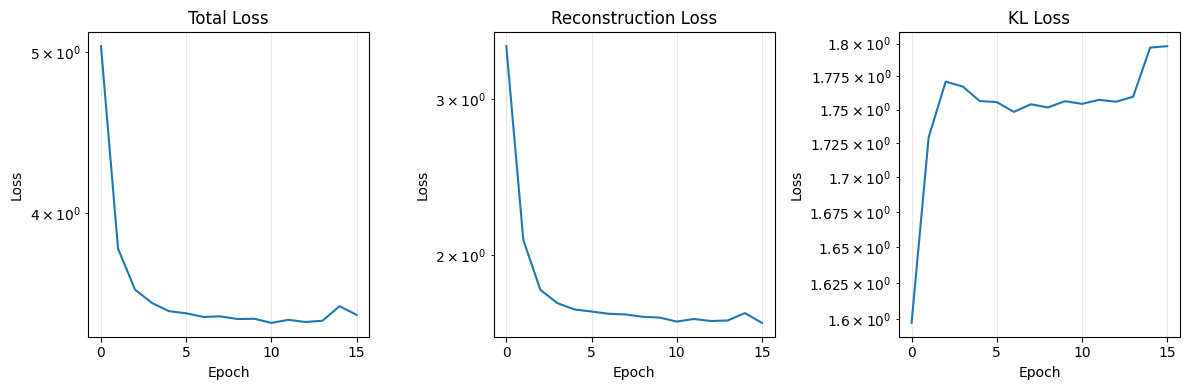

VAE training completed. Epochs run: 16
Latent features shape: (123255, 12)

4. K-means clustering on VAE latent features...
Clusters found: 15
Cluster centers shape: (15, 12)

5. Converting clusters -> binary forest/non-forest...

Cluster Statistics (top 5):
   cluster_id  mean_ndvi  mean_mndwi  pixel_count
0           0   0.611852   -0.281070        15297
1           1   0.474614   -0.334405        12369
2           2   0.273127   -0.355054         5617
3           3   0.610771   -0.162460         6007
4           4   0.567205   -0.300377        14543

Classified 11 clusters as Forest, 4 as Non-forest
Binary classification map ready.

-- Trimming district edge pixels for better visualization --
Original district pixels: 123,255
After erosion (interior): 119,245

6. Calculating forest area statistics for 2017...
Pixel dimensions: 195.0 x 198.8 m
Pixel area: 0.038767 km²

🌳 2017 VARIATIONAL AUTOENCODER + K-MEANS RESULTS:
  Forest pixels: 109,654
  Non-forest pixels: 13,464
  Total valid

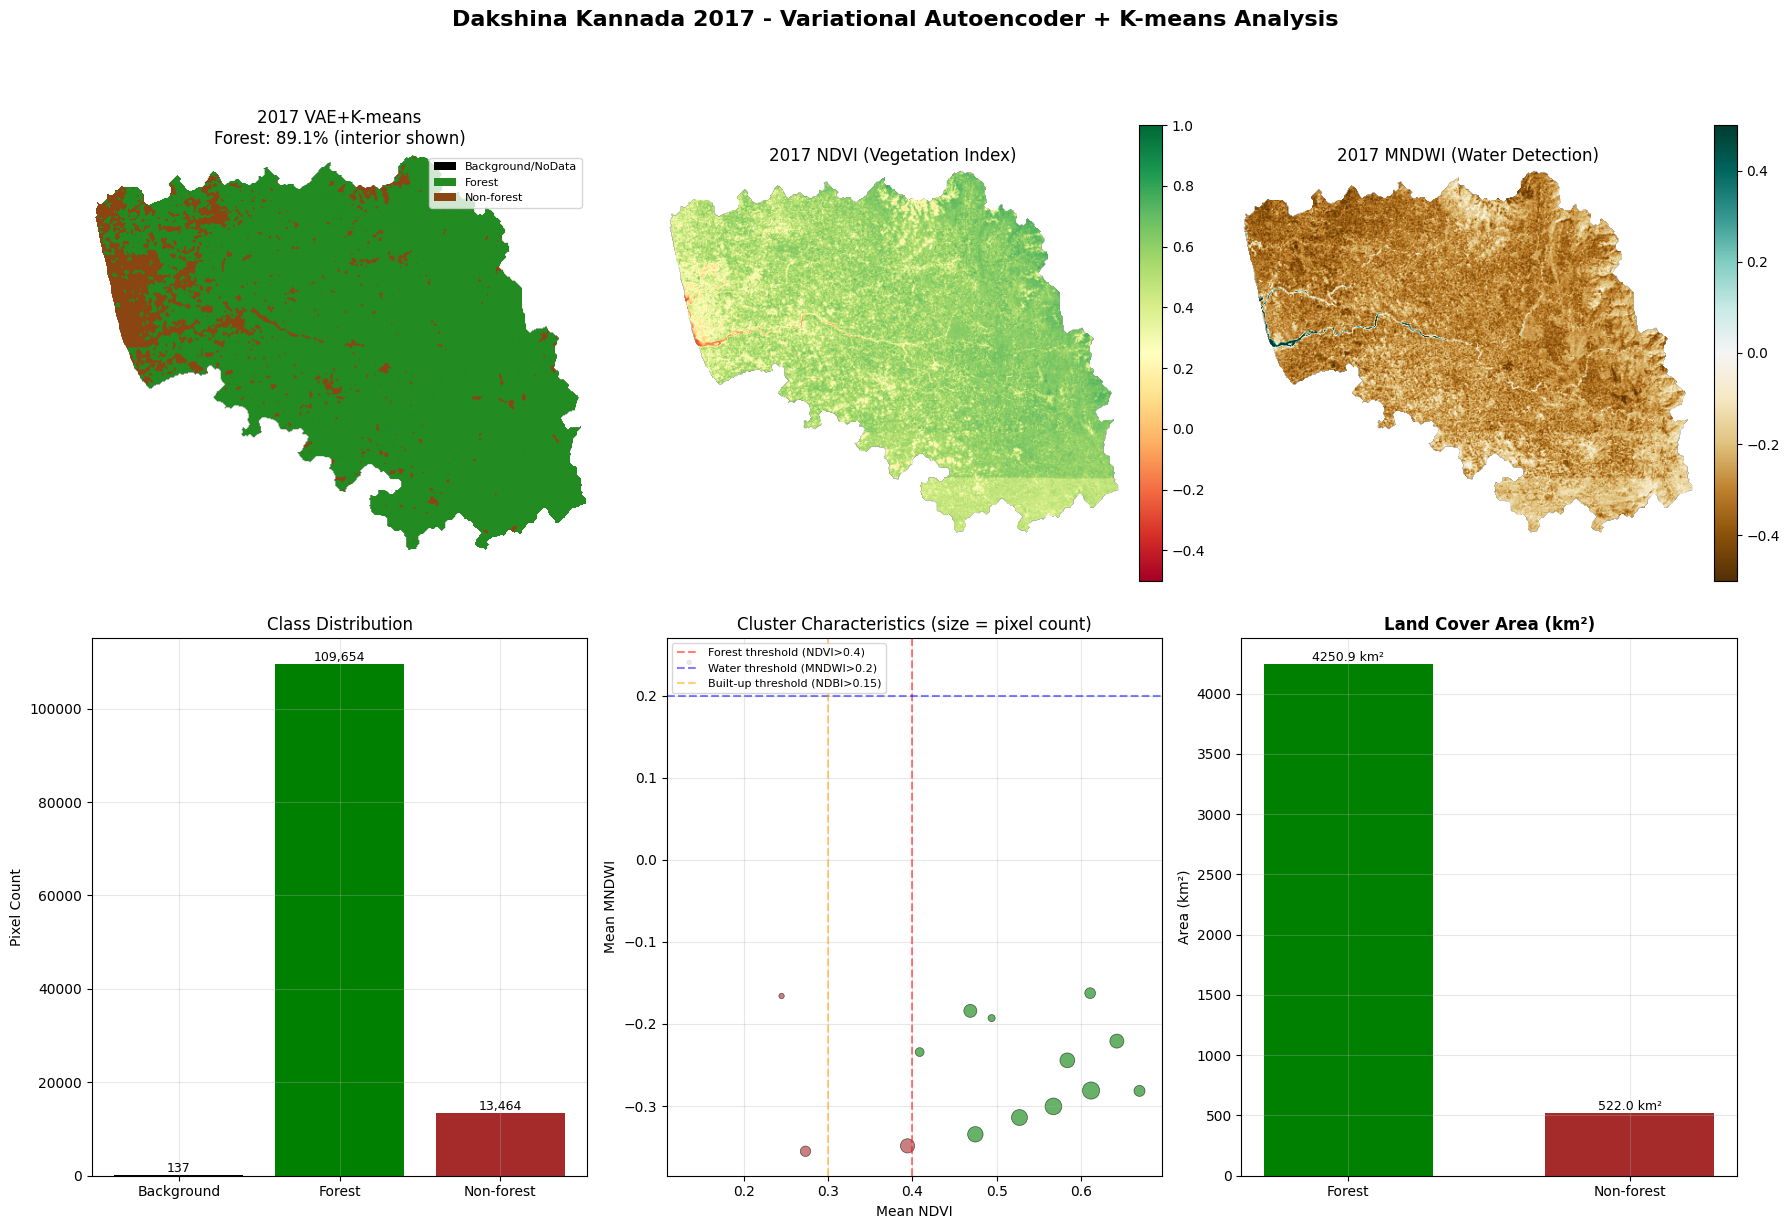


8. Saving 2017 VAE results...
✓ Classification map saved: /content/drive/MyDrive/Dakshina_Kannada_2017_VAE/DK_LULC_2017_VAE_Kmeans.tif
✓ Metrics saved: /content/drive/MyDrive/Dakshina_Kannada_2017_VAE/DK_2017_VAE_Metrics.csv
✓ Cluster analysis saved: /content/drive/MyDrive/Dakshina_Kannada_2017_VAE/DK_2017_VAE_Cluster_Analysis.csv
✓ Training history saved
✓ Report saved: /content/drive/MyDrive/Dakshina_Kannada_2017_VAE/DK_2017_VAE_Analysis_Report.txt

✅ 2017 VARIATIONAL AUTOENCODER + K-MEANS ANALYSIS COMPLETED!
Forest cover: 89.1% (4250.95 km²)
Output directory: /content/drive/MyDrive/Dakshina_Kannada_2017_VAE
Files created:
  • DK_LULC_2017_VAE_Kmeans.tif
  • DK_2017_VAE_Metrics.csv
  • DK_2017_VAE_Cluster_Analysis.csv
  • DK_2017_VAE_Analysis.png
  • DK_2017_VAE_Training_History.csv
  • results_2017_vae.pkl (for comparison)


In [ ]:
# ====================================================
# 2017 VARIATIONAL AUTOENCODER + K-MEANS ANALYSIS
# Same methodology as 2025 VAE model
# ====================================================

# ----------------- Install & imports -----------------
!pip install -q rasterio scikit-learn tensorflow matplotlib pandas seaborn

import os, random
import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from affine import Affine
from scipy.ndimage import median_filter, binary_erosion
from datetime import datetime

# Check GPU
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ====================================================
# PATHS AND PARAMETERS FOR 2017 VAE
# ====================================================

# PATHS
INPUT_FILE_2017 = "/content/drive/MyDrive/GEE_exports/DK_2017_Final_Mosaic.tif"
OUTPUT_DIR_2017 = "/content/drive/MyDrive/Dakshina_Kannada_2017_VAE"
os.makedirs(OUTPUT_DIR_2017, exist_ok=True)

# VAE Parameters (same as 2025)
PARAMS = {
    'scale_factor': 0.05,        # set to 1.0 for full resolution
    'n_clusters': 15,
    'vae_epochs': 50,
    'batch_size': 128,
    'latent_dim': 12,
    'sample_frac': None,         # quick test: 0.2
    'earlystop_patience': 5,
    'reduce_lr_patience': 3,
    'min_lr': 1e-6,
    'min_delta': 1e-6,
    'seed': 42,
    'learning_rate': 1e-3
}

# Files for saving models
VAE_CHECKPOINT = os.path.join(OUTPUT_DIR_2017, "best_vae_2017.keras")

# Reproducibility
np.random.seed(PARAMS['seed'])
random.seed(PARAMS['seed'])
tf.random.set_seed(PARAMS['seed'])

print("\n" + "="*70)
print("2017 VARIATIONAL AUTOENCODER + K-MEANS ANALYSIS")
print("Data: Sentinel-2 TOA (Top of Atmosphere)")
print("Period: January-February 2017")
print("="*70)

# ============== 1. LOAD 2017 DATA ==============
print("\n1. Loading 2017 satellite data...")
scale = PARAMS['scale_factor']

with rasterio.open(INPUT_FILE_2017) as src:
    profile = src.profile.copy()
    original_transform = src.transform
    original_bounds = src.bounds
    original_crs = src.crs
    data = src.read(
        out_shape=(src.count, int(src.height * scale), int(src.width * scale)),
        resampling=Resampling.bilinear
    ).astype(np.float32)

# Create district mask and normalize
district_mask = np.any(data > 0, axis=0)
max_val = np.nanmax(data)
if max_val <= 0:
    raise ValueError("2017 input image has no positive values")
data = data / max_val
h, w = data.shape[1], data.shape[2]

# Extract bands (adjust indices if needed)
if data.shape[0] >= 10:
    blue, green, red, nir, swir1 = data[0], data[1], data[2], data[6], data[8]
else:
    # Fallback if fewer bands
    print(f"Warning: Only {data.shape[0]} bands available, using first 5")
    blue, green, red, nir, swir1 = data[0], data[1], data[2], data[3], data[4]

# Calculate spectral indices
ndvi = np.clip((nir - red) / (nir + red + 1e-10), -1, 1)
mndwi = np.clip((green - swir1) / (green + swir1 + 1e-10), -1, 1)
ndbi = np.clip((swir1 - nir) / (swir1 + nir + 1e-10), -1, 1)

print(f"Data shape: {data.shape}")
print(f"District pixels: {np.sum(district_mask):,} (downscale {scale})")
print(f"Data range: {np.min(data):.4f} to {np.max(data):.4f}")

# ============== 2. FEATURE EXTRACTION ==============
print("\n2. Extracting features from 2017 data...")
features = []
coords = []
y_coords, x_coords = np.where(district_mask)

for y, x in zip(y_coords, x_coords):
    # Use available bands
    n_bands_to_use = min(6, data.shape[0])
    spectral_features = [data[b, y, x] for b in range(n_bands_to_use)]

    # Add indices
    feature_vec = spectral_features + [
        ndvi[y, x], mndwi[y, x], ndbi[y, x],
        np.std([data[b, y, x] for b in range(min(3, data.shape[0]))])
    ]
    features.append(feature_vec)
    coords.append((y, x))

features = np.array(features, dtype=np.float32)
features[np.isnan(features)] = 0
features[np.isinf(features)] = 0

print(f"Feature matrix shape: {features.shape}")
print(f"Features per pixel: {features.shape[1]}")

# Optional sampling for quick tests
if PARAMS['sample_frac'] is not None and 0 < PARAMS['sample_frac'] < 1:
    n_samples = int(len(features) * PARAMS['sample_frac'])
    idx = np.random.choice(len(features), n_samples, replace=False)
    features = features[idx]
    coords = [coords[i] for i in idx]
    print(f"Sampled {n_samples} pixels. New shape: {features.shape}")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# ============== 3. VAE MODEL ==============
print("\n3. Building Variational Autoencoder for 2017...")

input_dim = X_scaled.shape[1]
latent_dim = PARAMS['latent_dim']

# Sampling layer
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Encoder
encoder_inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(64, activation='relu')(encoder_inputs)
x = layers.Dense(32, activation='relu')(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(32, activation='relu')(latent_inputs)
x = layers.Dense(64, activation='relu')(x)
decoder_outputs = layers.Dense(input_dim, activation='linear')(x)
decoder = models.Model(latent_inputs, decoder_outputs, name="decoder")

# VAE class
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(tf.keras.losses.mse(data, reconstruction)) * input_dim
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

# Compile VAE
vae = VAE(encoder, decoder)
vae.compile(optimizer=optimizers.Adam(learning_rate=PARAMS['learning_rate']))

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='loss',
        patience=PARAMS['earlystop_patience'],
        restore_best_weights=True,
        verbose=1,
        min_delta=PARAMS['min_delta']
    ),
    ReduceLROnPlateau(
        monitor='loss',
        factor=0.5,
        patience=PARAMS['reduce_lr_patience'],
        min_lr=PARAMS['min_lr'],
        verbose=1
    ),
    ModelCheckpoint(
        VAE_CHECKPOINT,
        monitor='loss',
        save_best_only=True,
        verbose=1
    )
]

# Create dataset
dataset = tf.data.Dataset.from_tensor_slices(X_scaled).shuffle(1000).batch(PARAMS['batch_size'])

print(f"Training VAE (max epochs={PARAMS['vae_epochs']}) ...")
vae_history = vae.fit(
    dataset,
    epochs=PARAMS['vae_epochs'],
    verbose=1,
    callbacks=callbacks
)

# Plot training losses
plt.figure(figsize=(12, 4))
if 'loss' in vae_history.history:
    plt.subplot(1, 3, 1)
    plt.plot(vae_history.history['loss'])
    plt.yscale('log')
    plt.title('Total Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)

if 'reconstruction_loss' in vae_history.history:
    plt.subplot(1, 3, 2)
    plt.plot(vae_history.history['reconstruction_loss'])
    plt.yscale('log')
    plt.title('Reconstruction Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)

if 'kl_loss' in vae_history.history:
    plt.subplot(1, 3, 3)
    plt.plot(vae_history.history['kl_loss'])
    plt.yscale('log')
    plt.title('KL Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_2017, "vae_training_history_2017.png"), dpi=150)
plt.show()

print(f"VAE training completed. Epochs run: {len(vae_history.history['loss'])}")

# Extract latent features (use z_mean)
z_mean, z_log_var, z = encoder.predict(X_scaled, verbose=0)
print(f"Latent features shape: {z_mean.shape}")

# ============== 4. K-MEANS CLUSTERING ==============
print("\n4. K-means clustering on VAE latent features...")
kmeans = KMeans(n_clusters=PARAMS['n_clusters'], random_state=PARAMS['seed'], n_init=15)
labels = kmeans.fit_predict(z_mean)

print(f"Clusters found: {len(np.unique(labels))}")
print(f"Cluster centers shape: {kmeans.cluster_centers_.shape}")

# ============== 5. BINARY CLASSIFICATION ==============
print("\n5. Converting clusters -> binary forest/non-forest...")

cluster_stats = []
for cluster_id in range(PARAMS['n_clusters']):
    cluster_indices = np.where(labels == cluster_id)[0]
    if len(cluster_indices) > 0:
        cluster_ndvi = np.mean([ndvi[coords[i][0], coords[i][1]] for i in cluster_indices])
        cluster_mndwi = np.mean([mndwi[coords[i][0], coords[i][1]] for i in cluster_indices])
        cluster_ndbi = np.mean([ndbi[coords[i][0], coords[i][1]] for i in cluster_indices])
        cluster_stats.append({
            'cluster_id': cluster_id,
            'mean_ndvi': cluster_ndvi,
            'mean_mndwi': cluster_mndwi,
            'mean_ndbi': cluster_ndbi,
            'pixel_count': len(cluster_indices),
            'std_ndvi': np.std([ndvi[coords[i][0], coords[i][1]] for i in cluster_indices]),
            'std_mndwi': np.std([mndwi[coords[i][0], coords[i][1]] for i in cluster_indices])
        })

cluster_df = pd.DataFrame(cluster_stats).sort_values('cluster_id')

print("\nCluster Statistics (top 5):")
print(cluster_df[['cluster_id', 'mean_ndvi', 'mean_mndwi', 'pixel_count']].head())

# Classification rule (same as 2025 VAE)
def classify_cluster_vae(row):
    if row['mean_mndwi'] > 0.2 and row['mean_ndvi'] < 0.1:
        return 2  # Water (Non-forest)
    elif row['mean_ndbi'] > 0.15 and row['mean_ndvi'] < 0.3:
        return 2  # Built-up (Non-forest)
    elif row['mean_ndvi'] > 0.4:
        return 1  # Forest
    else:
        return 2  # Non-forest

cluster_df['binary_class'] = cluster_df.apply(classify_cluster_vae, axis=1)

# Count classes
forest_clusters = np.sum(cluster_df['binary_class'] == 1)
nonforest_clusters = np.sum(cluster_df['binary_class'] == 2)
print(f"\nClassified {forest_clusters} clusters as Forest, {nonforest_clusters} as Non-forest")

# Create binary map
binary_map = np.zeros((h, w), dtype=np.uint8)
for i, (y, x) in enumerate(coords):
    cid = int(labels[i])
    binary_map[y, x] = int(cluster_df.loc[cluster_df['cluster_id'] == cid, 'binary_class'].iloc[0])

# Apply median filter to reduce noise
binary_map = median_filter(binary_map, size=3)
print("Binary classification map ready.")

# Erode district mask for better visualization
print("\n-- Trimming district edge pixels for better visualization --")
trim_pixels = 2
district_eroded = binary_erosion(district_mask, iterations=trim_pixels)
print(f"Original district pixels: {np.sum(district_mask):,}")
print(f"After erosion (interior): {np.sum(district_eroded):,}")

# ============== 6. AREA CALCULATION ==============
print("\n6. Calculating forest area statistics for 2017...")

# Calculate pixel size in meters
new_transform = Affine(
    original_transform.a / scale, original_transform.b, original_transform.c,
    original_transform.d, original_transform.e / scale, original_transform.f
)

pixel_width_deg = abs(new_transform.a)
pixel_height_deg = abs(new_transform.e)
center_lat = (original_bounds.top + original_bounds.bottom) / 2.0
lat_rad = np.deg2rad(center_lat)

# Convert degrees to meters at this latitude
meters_per_deg_lat = 111132.92 - 559.82 * np.cos(2 * lat_rad) + 1.175 * np.cos(4 * lat_rad)
meters_per_deg_lon = 111412.84 * np.cos(lat_rad) - 93.5 * np.cos(3 * lat_rad) + 0.118 * np.cos(5 * lat_rad)

pixel_width_m = pixel_width_deg * meters_per_deg_lon
pixel_height_m = pixel_height_deg * meters_per_deg_lat
pixel_area_km2 = (pixel_width_m * pixel_height_m) / 1e6

print(f"Pixel dimensions: {pixel_width_m:.1f} x {pixel_height_m:.1f} m")
print(f"Pixel area: {pixel_area_km2:.6f} km²")

# Count pixels and calculate areas
forest_pixels = np.sum((binary_map == 1) & district_mask)
non_forest_pixels = np.sum((binary_map == 2) & district_mask)
total_district_pixels = forest_pixels + non_forest_pixels

forest_area_km2 = forest_pixels * pixel_area_km2
non_forest_area_km2 = non_forest_pixels * pixel_area_km2
total_district_area_km2 = forest_area_km2 + non_forest_area_km2
forest_percentage = (forest_pixels / total_district_pixels) * 100 if total_district_pixels > 0 else 0

print(f"\n🌳 2017 VARIATIONAL AUTOENCODER + K-MEANS RESULTS:")
print(f"  Forest pixels: {forest_pixels:,}")
print(f"  Non-forest pixels: {non_forest_pixels:,}")
print(f"  Total valid pixels: {total_district_pixels:,}")
print(f"  Forest area: {forest_area_km2:.2f} km²")
print(f"  Non-forest area: {non_forest_area_km2:.2f} km²")
print(f"  Total district area: {total_district_area_km2:.2f} km²")
print(f"  Forest percentage: {forest_percentage:.1f}%")

# ============== 7. VISUALIZATION ==============
print("\n7. Creating visualizations for 2017 VAE...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Dakshina Kannada 2017 - Variational Autoencoder + K-means Analysis',
             fontsize=16, fontweight='bold', y=1.02)

cmap_binary = ListedColormap(['#000000', '#228B22', '#8B4513'])

# 1. Classification Map (with eroded mask)
masked_vae_plot = np.ma.masked_where(~district_eroded, binary_map)
axes[0,0].imshow(masked_vae_plot, cmap=cmap_binary, vmin=0, vmax=2)
axes[0,0].set_title(f'2017 VAE+K-means\nForest: {forest_percentage:.1f}% (interior shown)')
axes[0,0].axis('off')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#000000', label='Background/NoData'),
    Patch(facecolor='#228B22', label='Forest'),
    Patch(facecolor='#8B4513', label='Non-forest')
]
axes[0,0].legend(handles=legend_elements, loc='upper right', fontsize=8)

# 2. NDVI Map
ndvi_masked = np.ma.masked_where(~district_eroded, ndvi)
im1 = axes[0,1].imshow(ndvi_masked, cmap='RdYlGn', vmin=-0.5, vmax=1)
axes[0,1].set_title('2017 NDVI (Vegetation Index)')
axes[0,1].axis('off')
plt.colorbar(im1, ax=axes[0,1], fraction=0.046, pad=0.04)

# 3. MNDWI Map (Water Detection)
mndwi_masked = np.ma.masked_where(~district_eroded, mndwi)
im2 = axes[0,2].imshow(mndwi_masked, cmap='BrBG', vmin=-0.5, vmax=0.5)
axes[0,2].set_title('2017 MNDWI (Water Detection)')
axes[0,2].axis('off')
plt.colorbar(im2, ax=axes[0,2], fraction=0.046, pad=0.04)

# 4. Class Distribution
unique, counts = np.unique(binary_map[district_mask], return_counts=True)
class_names = ['Background', 'Forest', 'Non-forest']
colors = ['black', 'green', 'brown']

# Filter for classes present
present_classes = []
present_counts = []
present_colors = []

for i, class_val in enumerate(unique):
    if class_val < len(class_names):
        present_classes.append(class_names[class_val])
        present_counts.append(counts[i])
        if class_val < len(colors):
            present_colors.append(colors[class_val])

if present_classes:
    axes[1,0].bar(present_classes, present_counts, color=present_colors)
    axes[1,0].set_title('Class Distribution')
    axes[1,0].set_ylabel('Pixel Count')
    axes[1,0].grid(True, alpha=0.3)

    # Add value labels
    for i, (cls, count) in enumerate(zip(present_classes, present_counts)):
        axes[1,0].text(i, count, f'{count:,}', ha='center', va='bottom', fontsize=9)
else:
    axes[1,0].text(0.5, 0.5, 'No classes found',
                  ha='center', va='center', transform=axes[1,0].transAxes)
    axes[1,0].axis('off')

# 5. Cluster Characteristics Scatter Plot
if not cluster_df.empty:
    scatter = axes[1,1].scatter(
        cluster_df['mean_ndvi'],
        cluster_df['mean_mndwi'],
        s=cluster_df['pixel_count']/100,
        alpha=0.6,
        c=cluster_df['binary_class'].map({1: 'green', 2: 'brown'}),
        edgecolors='black', linewidth=0.5
    )
    axes[1,1].axvline(x=0.4, color='red', linestyle='--', alpha=0.5, label='Forest threshold (NDVI>0.4)')
    axes[1,1].axhline(y=0.2, color='blue', linestyle='--', alpha=0.5, label='Water threshold (MNDWI>0.2)')
    axes[1,1].axvline(x=0.3, color='orange', linestyle='--', alpha=0.5, label='Built-up threshold (NDBI>0.15)')
    axes[1,1].set_xlabel('Mean NDVI')
    axes[1,1].set_ylabel('Mean MNDWI')
    axes[1,1].set_title('Cluster Characteristics (size = pixel count)')
    axes[1,1].legend(loc='upper left', fontsize=8)
    axes[1,1].grid(True, alpha=0.3)
else:
    axes[1,1].text(0.5, 0.5, 'No cluster data available',
                  ha='center', va='center', transform=axes[1,1].transAxes)
    axes[1,1].axis('off')

# 6. Area Chart
categories = ['Forest', 'Non-forest']
areas = [forest_area_km2, non_forest_area_km2]
colors_area = ['green', 'brown']

bars = axes[1,2].bar(categories, areas, color=colors_area, width=0.6)
axes[1,2].set_title('Land Cover Area (km²)', fontweight='bold')
axes[1,2].set_ylabel('Area (km²)')
axes[1,2].grid(True, alpha=0.3)

# Add value labels
for i, (category, area) in enumerate(zip(categories, areas)):
    axes[1,2].text(i, area, f'{area:.1f} km²', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_2017, "DK_2017_VAE_Analysis.png"), dpi=300, bbox_inches='tight')
plt.show()

# ============== 8. SAVE RESULTS ==============
print("\n8. Saving 2017 VAE results...")

# Save classification map
masked_save = binary_map.copy().astype(np.uint8)
masked_save[~district_eroded] = 255  # Use 255 as NoData

meta = profile.copy()
meta.update({
    "driver": "GTiff",
    "height": h,
    "width": w,
    "count": 1,
    "dtype": "uint8",
    "nodata": 255,
    "transform": new_transform,
    "compress": "LZW",
    "crs": original_crs
})

output_file = os.path.join(OUTPUT_DIR_2017, "DK_LULC_2017_VAE_Kmeans.tif")
with rasterio.open(output_file, "w", **meta) as dst:
    dst.write(masked_save, 1)
    try:
        dst.write_colormap(1, {
            1: (34, 139, 34),   # Forest green
            2: (139, 69, 19),   # Brown
            255: (0, 0, 0)      # Black for NoData
        })
    except:
        print("Note: Could not write colormap (not critical)")

print(f"✓ Classification map saved: {output_file}")

# Save metrics
results_data = {
    'Year': [2017],
    'Model': ['Variational Autoencoder + K-means'],
    'Dataset': ['Sentinel-2 TOA'],
    'Period': ['Jan-Feb 2017'],
    'Forest_Pixels': [forest_pixels],
    'NonForest_Pixels': [non_forest_pixels],
    'Total_Pixels': [total_district_pixels],
    'Forest_Percentage': [forest_percentage],
    'Forest_Area_km2': [forest_area_km2],
    'NonForest_Area_km2': [non_forest_area_km2],
    'Total_Area_km2': [total_district_area_km2],
    'Pixel_Area_km2': [pixel_area_km2],
    'Scale_Factor': [scale],
    'N_Clusters': [PARAMS['n_clusters']],
    'Latent_Dim': [PARAMS['latent_dim']],
    'VAE_Epochs': [len(vae_history.history['loss'])],
    'Final_Loss': [vae_history.history['loss'][-1] if len(vae_history.history['loss']) > 0 else None],
    'Final_Reconstruction_Loss': [vae_history.history['reconstruction_loss'][-1] if 'reconstruction_loss' in vae_history.history else None],
    'Final_KL_Loss': [vae_history.history['kl_loss'][-1] if 'kl_loss' in vae_history.history else None],
    'Validation': ['No Dynamic World for 2017'],
    'Processing_Date': [datetime.now().strftime('%Y-%m-%d %H:%M:%S')]
}

results_df = pd.DataFrame(results_data)
metrics_file = os.path.join(OUTPUT_DIR_2017, "DK_2017_VAE_Metrics.csv")
results_df.to_csv(metrics_file, index=False)
print(f"✓ Metrics saved: {metrics_file}")

# Save cluster analysis
cluster_file = os.path.join(OUTPUT_DIR_2017, "DK_2017_VAE_Cluster_Analysis.csv")
cluster_df.to_csv(cluster_file, index=False)
print(f"✓ Cluster analysis saved: {cluster_file}")

# Save training history
vae_history_df = pd.DataFrame(vae_history.history)
vae_history_file = os.path.join(OUTPUT_DIR_2017, "DK_2017_VAE_Training_History.csv")
vae_history_df.to_csv(vae_history_file, index=False)
print(f"✓ Training history saved")

# Save summary report
report_file = os.path.join(OUTPUT_DIR_2017, "DK_2017_VAE_Analysis_Report.txt")
with open(report_file, 'w') as f:
    f.write("="*80 + "\n")
    f.write("DAKSHINA KANNADA 2017 FOREST COVER ANALYSIS REPORT\n")
    f.write("Variational Autoencoder + K-means Method\n")
    f.write("="*80 + "\n\n")

    f.write("SUMMARY\n")
    f.write("-"*40 + "\n")
    f.write(f"Forest cover in 2017: {forest_percentage:.1f}%\n")
    f.write(f"Forest area: {forest_area_km2:.2f} km²\n")
    f.write(f"Non-forest area: {non_forest_area_km2:.2f} km²\n")
    f.write(f"Total district area: {total_district_area_km2:.2f} km²\n\n")

    f.write("METHODOLOGY\n")
    f.write("-"*40 + "\n")
    f.write("1. Data: Sentinel-2 TOA (Top of Atmosphere)\n")
    f.write("2. Period: January-February 2017\n")
    f.write("3. Processing: Variational Autoencoder + K-means\n")
    f.write("4. VAE Architecture:\n")
    f.write("   - Encoder: Input → Dense(64) → Dense(32) → Latent space (z_mean, z_log_var)\n")
    f.write("   - Latent dimension: 12\n")
    f.write("   - Decoder: Latent → Dense(32) → Dense(64) → Output\n")
    f.write("5. Loss function: Reconstruction loss + KL divergence\n")
    f.write("6. Clustering: K-means on latent space (z_mean)\n")
    f.write("7. Classification rules:\n")
    f.write("   - Forest: NDVI > 0.4\n")
    f.write("   - Water: MNDWI > 0.2 and NDVI < 0.1 (classified as non-forest)\n")
    f.write("   - Built-up: NDBI > 0.15 and NDVI < 0.3 (classified as non-forest)\n")
    f.write("   - Other: All other pixels as non-forest\n")
    f.write(f"8. Parameters: {PARAMS['n_clusters']} clusters, {PARAMS['latent_dim']} latent dimensions\n")
    f.write(f"9. Training: {len(vae_history.history['loss'])} VAE epochs\n\n")

    f.write("DATA QUALITY NOTES\n")
    f.write("-"*40 + "\n")
    f.write("1. 2017 data is TOA (Top of Atmosphere) reflectance\n")
    f.write("2. 2025 comparison data is SR (Surface Reflectance)\n")
    f.write("3. Different atmospheric correction methods\n")
    f.write("4. Same VAE architecture and classification thresholds as 2025\n")
    f.write("5. No Dynamic World validation for 2017\n\n")

    f.write("VAE ADVANTAGES OVER BASIC AUTOENCODER\n")
    f.write("-"*40 + "\n")
    f.write("1. Probabilistic latent space representation\n")
    f.write("2. Regularization via KL divergence\n")
    f.write("3. Better generation capabilities\n")
    f.write("4. More robust to outliers and noise\n")
    f.write("5. Smooth interpolation in latent space\n")

print(f"✓ Report saved: {report_file}")

# ============== SAVE RESULTS FOR COMPARISON ==============
results_2017_vae = {
    'year': 2017,
    'model': 'Variational_Autoencoder_Kmeans',
    'binary_map': binary_map,
    'forest_percentage': forest_percentage,
    'forest_area_km2': forest_area_km2,
    'forest_pixels': forest_pixels,
    'total_pixels': total_district_pixels,
    'pixel_area_km2': pixel_area_km2,
    'display_mask': district_eroded,
    'district_mask': district_mask,
    'ndvi': ndvi,
    'results_df': results_df,
    'cluster_df': cluster_df,
    'original_shape': (h, w),
    'transform': new_transform,
    'meta': meta
}

# Save results for comparison later
import pickle
results_2017_vae_file = os.path.join(OUTPUT_DIR_2017, "results_2017_vae.pkl")
with open(results_2017_vae_file, 'wb') as f:
    pickle.dump(results_2017_vae, f)

print("\n" + "="*70)
print("✅ 2017 VARIATIONAL AUTOENCODER + K-MEANS ANALYSIS COMPLETED!")
print("="*70)
print(f"Forest cover: {forest_percentage:.1f}% ({forest_area_km2:.2f} km²)")
print(f"Output directory: {OUTPUT_DIR_2017}")
print(f"Files created:")
print(f"  • DK_LULC_2017_VAE_Kmeans.tif")
print(f"  • DK_2017_VAE_Metrics.csv")
print(f"  • DK_2017_VAE_Cluster_Analysis.csv")
print(f"  • DK_2017_VAE_Analysis.png")
print(f"  • DK_2017_VAE_Training_History.csv")
print(f"  • results_2017_vae.pkl (for comparison)")